In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker 
import seaborn as sns
import os
import numpy as np
 
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 10)


## Importar os datasets

In [2]:
def import_dataset(file_path):
    try:
        dataset = pd.read_csv(file_path)
        print("Dataset imported successfully!")
        return dataset
    except Exception as e:
        print(f"An error occurred while importing the dataset: {e}")
        return None

In [3]:
condominios_fracoes = import_dataset('datasets/condominios_fracoes.csv')
condominios_fracoes = condominios_fracoes.map(lambda x: x.lower().strip() if isinstance(x, str) else x)
 
manutencoes_reparacoes = import_dataset('datasets/manutencoes_reparacoes.csv')
manutencoes_reparacoes = manutencoes_reparacoes.map(lambda x: x.lower().strip() if isinstance(x, str) else x)
 
ocorrencias_reclamacoes = import_dataset('datasets/ocorrencias_reclamacoes.csv')
ocorrencias_reclamacoes = ocorrencias_reclamacoes.map(lambda x: x.lower().strip() if isinstance(x, str) else x)

pagamentos_quotas = import_dataset('datasets/pagamentos_quotas.csv')
pagamentos_quotas = pagamentos_quotas.map(lambda x: x.lower().strip() if isinstance(x, str) else x)

Dataset imported successfully!
Dataset imported successfully!
Dataset imported successfully!
Dataset imported successfully!


## Informações dos datasets

In [4]:
condominios_fracoes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2510 entries, 0 to 2509
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fração_id          2510 non-null   object 
 1   condominio         2510 non-null   object 
 2   bloco              2510 non-null   object 
 3   andar              2510 non-null   int64  
 4   porta              2510 non-null   object 
 5   tipo_fracao        2510 non-null   object 
 6   area_m2            2468 non-null   float64
 7   quota_mensal       2510 non-null   float64
 8   proprietario_nome  2510 non-null   object 
 9   proprietario_nif   2510 non-null   int64  
 10  data_aquisicao     2469 non-null   object 
 11  valor_aquisicao    2453 non-null   object 
 12  situacao           2449 non-null   object 
dtypes: float64(2), int64(2), object(9)
memory usage: 255.1+ KB


In [5]:
manutencoes_reparacoes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 820 entries, 0 to 819
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   manutencao_id     820 non-null    object 
 1   condominio        820 non-null    object 
 2   tipo_intervencao  820 non-null    object 
 3   area_afetada      820 non-null    object 
 4   descricao         797 non-null    object 
 5   data_reportada    820 non-null    object 
 6   data_inicio       820 non-null    object 
 7   data_conclusao    775 non-null    object 
 8   fornecedor        807 non-null    object 
 9   custo_total       805 non-null    float64
 10  urgencia          820 non-null    object 
 11  estado            820 non-null    object 
dtypes: float64(1), object(11)
memory usage: 77.0+ KB


In [6]:
ocorrencias_reclamacoes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1230 entries, 0 to 1229
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ocorrencia_id       1230 non-null   object
 1   fração_origem       1230 non-null   object
 2   tipo                1230 non-null   object
 3   descricao_completa  1202 non-null   object
 4   data_ocorrencia     1230 non-null   object
 5   gravidade           1230 non-null   int64 
 6   resolvido           1230 non-null   object
 7   acao_tomada         1212 non-null   object
dtypes: int64(1), object(7)
memory usage: 77.0+ KB


In [7]:
pagamentos_quotas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60340 entries, 0 to 60339
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pagamento_id      60340 non-null  object 
 1   fração_id         60340 non-null  object 
 2   mes_referencia    60340 non-null  object 
 3   data_vencimento   60340 non-null  object 
 4   data_pagamento    59588 non-null  object 
 5   valor_quota       60340 non-null  object 
 6   multa             59700 non-null  float64
 7   estado            60340 non-null  object 
 8   metodo_pagamento  59016 non-null  object 
dtypes: float64(1), object(8)
memory usage: 4.1+ MB


In [8]:
condominios_fracoes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2510 entries, 0 to 2509
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fração_id          2510 non-null   object 
 1   condominio         2510 non-null   object 
 2   bloco              2510 non-null   object 
 3   andar              2510 non-null   int64  
 4   porta              2510 non-null   object 
 5   tipo_fracao        2510 non-null   object 
 6   area_m2            2468 non-null   float64
 7   quota_mensal       2510 non-null   float64
 8   proprietario_nome  2510 non-null   object 
 9   proprietario_nif   2510 non-null   int64  
 10  data_aquisicao     2469 non-null   object 
 11  valor_aquisicao    2453 non-null   object 
 12  situacao           2449 non-null   object 
dtypes: float64(2), int64(2), object(9)
memory usage: 255.1+ KB


## Valores nulos nos datasets

In [9]:
condominios_fracoes.isnull().sum()

fração_id             0
condominio            0
bloco                 0
andar                 0
porta                 0
tipo_fracao           0
area_m2              42
quota_mensal          0
proprietario_nome     0
proprietario_nif      0
data_aquisicao       41
valor_aquisicao      57
situacao             61
dtype: int64

In [10]:
manutencoes_reparacoes.isnull().sum()

manutencao_id        0
condominio           0
tipo_intervencao     0
area_afetada         0
descricao           23
data_reportada       0
data_inicio          0
data_conclusao      45
fornecedor          13
custo_total         15
urgencia             0
estado               0
dtype: int64

In [11]:
ocorrencias_reclamacoes.isnull().sum()

ocorrencia_id          0
fração_origem          0
tipo                   0
descricao_completa    28
data_ocorrencia        0
gravidade              0
resolvido              0
acao_tomada           18
dtype: int64

In [12]:
pagamentos_quotas.isnull().sum()

pagamento_id           0
fração_id              0
mes_referencia         0
data_vencimento        0
data_pagamento       752
valor_quota            0
multa                640
estado                 0
metodo_pagamento    1324
dtype: int64

## Duplicados nos datasets

In [13]:
condominios_fracoes.duplicated().sum()

np.int64(8)

In [14]:
condominios_fracoes[condominios_fracoes.duplicated(subset=[ 'fração_id', 'condominio', 'bloco', 'andar', 'porta', 'tipo_fracao','area_m2', 'quota_mensal', 'proprietario_nome', 'proprietario_nif','data_aquisicao', 'valor_aquisicao', 'situacao'], keep = False)].sort_values('fração_id')

,fração_id,condominio,bloco,andar,porta,tipo_fracao,area_m2,quota_mensal,proprietario_nome,proprietario_nif,data_aquisicao,valor_aquisicao,situacao
480,fr0001,condomínio central,c,8,8f,t2,87.5,129.44,josé fonseca sousa,0,2022-08-22,122563.63,ocupada
2331,fr0001,condomínio central,c,8,8f,t2,87.5,129.44,josé fonseca sousa,0,2022-08-22,122563.63,ocupada
711,fr0002,residencial atlântico,a,7,7e,t1,56.1,58.59,joana pinto simões,139257710,2007-04-21,57330.55,ocupada
1547,fr0002,residencial atlântico,a,7,7e,t1,56.1,58.59,joana pinto simões,139257710,2007-04-21,57330.55,ocupada
1119,fr0004,jardins da cidade,norte,4,4c,t2,70.3,79.95,fernando simões sousa,137591513,2009-11-10,66850.48,arrendada
2435,fr0004,jardins da cidade,norte,4,4c,t2,70.3,79.95,fernando simões sousa,137591513,2009-11-10,66850.48,arrendada
7,fr0005,condomínio central,c,5,5d,t3,124.2,178.97,antónio ramos sousa,125914876,2012-06-29,154259.41,ocupada
2151,fr0005,condomínio central,c,5,5d,t3,124.2,178.97,antónio ramos sousa,125914876,2012-06-29,154259.41,ocupada
801,fr0007,residencial atlântico,c,0,0e,t2,86.7,102.49,manuel marques rodrigues,101405605,2013-11-05,98386.31,arrendada
1161,fr0007,residencial atlântico,c,0,0e,t2,86.7,102.49,manuel marques rodrigues,101405605,2013-11-05,98386.31,arrendada


In [15]:
manutencoes_reparacoes.duplicated().sum()

np.int64(18)

In [16]:
manutencoes_reparacoes[manutencoes_reparacoes.duplicated(subset=[ 'manutencao_id', 'condominio', 'tipo_intervencao', 'area_afetada','descricao', 'data_reportada', 'data_inicio', 'data_conclusao','fornecedor', 'custo_total', 'urgencia', 'estado'], keep = False)].sort_values('manutencao_id')

,manutencao_id,condominio,tipo_intervencao,area_afetada,descricao,data_reportada,data_inicio,data_conclusao,fornecedor,custo_total,urgencia,estado
30,mn00031,quinta das palmeiras,manutenção preventiva,elevador,necessária inspeção periódica obrigatória,2024-07-05,2024-07-05,2024-07-08,primeworks group,2431.71,crítica,concluído
800,mn00031,quinta das palmeiras,manutenção preventiva,elevador,necessária inspeção periódica obrigatória,2024-07-05,2024-07-05,2024-07-08,primeworks group,2431.71,crítica,concluído
119,mn00120,vila verde,inspeção,garagem,marcações no chão necessitam repintura,2025-04-10,2025-04-11,2025-04-12,ultrafix & filhos,3150.53,crítica,concluído
811,mn00120,vila verde,inspeção,garagem,marcações no chão necessitam repintura,2025-04-10,2025-04-11,2025-04-12,ultrafix & filhos,3150.53,crítica,concluído
157,mn00158,quinta das palmeiras,melhoria,piscina,vedação de segurança danificada,2024-06-15,2024-07-04,2024-07-14,proserviços group,564.26,baixa,concluído
814,mn00158,quinta das palmeiras,melhoria,piscina,vedação de segurança danificada,2024-06-15,2024-07-04,2024-07-14,proserviços group,564.26,baixa,concluído
193,mn00194,quinta das palmeiras,melhoria,elevador,botões do painel não respondem,2024-06-05,2024-06-06,2024-06-10,primeworks group,5895.70,crítica,concluído
818,mn00194,quinta das palmeiras,melhoria,elevador,botões do painel não respondem,2024-06-05,2024-06-06,2024-06-10,primeworks group,5895.70,crítica,concluído
809,mn00201,torres do sol,reparação urgente,garagem,sistema de ventilação com problemas,2023-10-02,2023-10-07,2023-10-14,globaltec group,1310.78,alta,concluído
200,mn00201,torres do sol,reparação urgente,garagem,sistema de ventilação com problemas,2023-10-02,2023-10-07,2023-10-14,globaltec group,1310.78,alta,concluído


In [17]:
ocorrencias_reclamacoes.duplicated().sum()

np.int64(26)

In [18]:
ocorrencias_reclamacoes[ocorrencias_reclamacoes.duplicated(subset=['ocorrencia_id', 'fração_origem', 'tipo', 'descricao_completa','data_ocorrencia', 'gravidade', 'resolvido', 'acao_tomada'], keep = False)].sort_values('ocorrencia_id')

,ocorrencia_id,fração_origem,tipo,descricao_completa,data_ocorrencia,gravidade,resolvido,acao_tomada
177,oc00178,fr2285,ruído,obras não autorizadas no apartamento 5e fora d...,2024-07-10 16:43,2,true,morador notificado por escrito. situação regul...
1226,oc00178,fr2285,ruído,obras não autorizadas no apartamento 5e fora d...,2024-07-10 16:43,2,true,morador notificado por escrito. situação regul...
193,oc00194,fr0203,limpeza,empresa de limpeza não aparece há duas semanas...,2025-07-15 16:43,3,1,situação regularizada. empresa de limpeza noti...
1220,oc00194,fr0203,limpeza,empresa de limpeza não aparece há duas semanas...,2025-07-15 16:43,3,1,situação regularizada. empresa de limpeza noti...
214,oc00215,fr2227,estacionamento,"carro abandonado na garagem há meses, ocupando...",2025-01-25 16:43,3,false,em análise pela administração
1222,oc00215,fr2227,estacionamento,"carro abandonado na garagem há meses, ocupando...",2025-01-25 16:43,3,false,em análise pela administração
251,oc00252,fr1717,ruído,barulho excessivo proveniente do apartamento 4...,2024-09-03 16:43,3,false,em análise pela administração
1211,oc00252,fr1717,ruído,barulho excessivo proveniente do apartamento 4...,2024-09-03 16:43,3,false,em análise pela administração
259,oc00260,fr1583,vandalismo,caixas de correio arrombadas durante a noite. ...,2024-03-31 16:43,3,false,a resolver
1200,oc00260,fr1583,vandalismo,caixas de correio arrombadas durante a noite. ...,2024-03-31 16:43,3,false,a resolver


In [19]:
pagamentos_quotas.duplicated().sum()

np.int64(96)

In [20]:
pagamentos_quotas[pagamentos_quotas.duplicated(subset=['pagamento_id', 'fração_id', 'mes_referencia', 'data_vencimento','data_pagamento', 'valor_quota', 'multa', 'estado', 'metodo_pagamento'], keep = False)].sort_values('fração_id')

,pagamento_id,fração_id,mes_referencia,data_vencimento,data_pagamento,valor_quota,multa,estado,metodo_pagamento
60246,pg053265,fr0052,2025-01,2025-02-07,2025-03-05,42.13,0.73,em atraso,mb way
53264,pg053265,fr0052,2025-01,2025-02-07,2025-03-05,42.13,0.73,em atraso,mb way
60288,pg045280,fr0076,2024-06,2024-07-08,2024-07-03,146.29,0.00,pago,transf.
45279,pg045280,fr0076,2024-06,2024-07-08,2024-07-03,146.29,0.00,pago,transf.
652,pg000653,fr0080,2025-05,2025-06-07,2025-07-17,63.22,1.69,em atraso,transferência
...,...,...,...,...,...,...,...,...,...
60339,pg041057,fr2433,2024-05,2024-06-07,2024-06-29,106.3,1.56,em atraso,transferência
36457,pg036458,fr2443,2025-08,2025-09-07,2025-09-04,144.73,0.00,pago,mb way
60313,pg036458,fr2443,2025-08,2025-09-07,2025-09-04,144.73,0.00,pago,mb way
7299,pg007300,fr2445,2025-06,2025-07-08,2025-07-09,158.83,0.00,pago,transferência


## Limpeza de Duplicados

In [21]:
condominios_fracoes_clean = condominios_fracoes.drop_duplicates(keep='first').copy()
manutencoes_reparacoes_clean = manutencoes_reparacoes.drop_duplicates(keep='first').copy()
ocorrencias_reclamacoes_clean = ocorrencias_reclamacoes.drop_duplicates(keep='first').copy()
pagamentos_quotas_clean = pagamentos_quotas.drop_duplicates(keep='first').copy()
 

In [22]:
condominios_fracoes_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2502 entries, 0 to 2509
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fração_id          2502 non-null   object 
 1   condominio         2502 non-null   object 
 2   bloco              2502 non-null   object 
 3   andar              2502 non-null   int64  
 4   porta              2502 non-null   object 
 5   tipo_fracao        2502 non-null   object 
 6   area_m2            2460 non-null   float64
 7   quota_mensal       2502 non-null   float64
 8   proprietario_nome  2502 non-null   object 
 9   proprietario_nif   2502 non-null   int64  
 10  data_aquisicao     2461 non-null   object 
 11  valor_aquisicao    2445 non-null   object 
 12  situacao           2441 non-null   object 
dtypes: float64(2), int64(2), object(9)
memory usage: 273.7+ KB


In [23]:
'''
Foram removidos os duplicados. Inicialmente tinhamos 2510 entradas, e 8 duplicados, o que fez com que o dataset ficasse com 2502 entradas.
'''

'\nForam removidos os duplicados. Inicialmente tinhamos 2510 entradas, e 8 duplicados, o que fez com que o dataset ficasse com 2502 entradas.\n'

In [24]:
manutencoes_reparacoes_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 802 entries, 0 to 812
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   manutencao_id     802 non-null    object 
 1   condominio        802 non-null    object 
 2   tipo_intervencao  802 non-null    object 
 3   area_afetada      802 non-null    object 
 4   descricao         779 non-null    object 
 5   data_reportada    802 non-null    object 
 6   data_inicio       802 non-null    object 
 7   data_conclusao    757 non-null    object 
 8   fornecedor        789 non-null    object 
 9   custo_total       787 non-null    float64
 10  urgencia          802 non-null    object 
 11  estado            802 non-null    object 
dtypes: float64(1), object(11)
memory usage: 81.5+ KB


In [25]:
'''
Validamos que já não existem duplicados no dataset condominios_fracoes_clean.
'''

'\nValidamos que já não existem duplicados no dataset condominios_fracoes_clean.\n'

In [26]:
manutencoes_reparacoes_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 802 entries, 0 to 812
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   manutencao_id     802 non-null    object 
 1   condominio        802 non-null    object 
 2   tipo_intervencao  802 non-null    object 
 3   area_afetada      802 non-null    object 
 4   descricao         779 non-null    object 
 5   data_reportada    802 non-null    object 
 6   data_inicio       802 non-null    object 
 7   data_conclusao    757 non-null    object 
 8   fornecedor        789 non-null    object 
 9   custo_total       787 non-null    float64
 10  urgencia          802 non-null    object 
 11  estado            802 non-null    object 
dtypes: float64(1), object(11)
memory usage: 81.5+ KB


In [27]:
'''
Foram removidos os duplicados. Inicialmente tinhamos 820 entradas, e 18 duplicados, o que fez com que o dataset ficasse com 802 entradas.
'''

'\nForam removidos os duplicados. Inicialmente tinhamos 820 entradas, e 18 duplicados, o que fez com que o dataset ficasse com 802 entradas.\n'

In [28]:
manutencoes_reparacoes_clean.duplicated().sum()

np.int64(0)

In [29]:
'''
Validamos que já não existem duplicados no dataset manutencoes_reparacoes_clean.
'''

'\nValidamos que já não existem duplicados no dataset manutencoes_reparacoes_clean.\n'

In [30]:
ocorrencias_reclamacoes_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1204 entries, 0 to 1228
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ocorrencia_id       1204 non-null   object
 1   fração_origem       1204 non-null   object
 2   tipo                1204 non-null   object
 3   descricao_completa  1176 non-null   object
 4   data_ocorrencia     1204 non-null   object
 5   gravidade           1204 non-null   int64 
 6   resolvido           1204 non-null   object
 7   acao_tomada         1186 non-null   object
dtypes: int64(1), object(7)
memory usage: 84.7+ KB


In [31]:
ocorrencias_reclamacoes_clean['tipo'].value_counts()

tipo
ruído             356
infiltração       214
limpeza           169
segurança         165
vandalismo        133
estacionamento    114
ruido              21
seguranca           6
infiltracao         6
humidade            5
higiene             3
barulho             3
vandalism           3
parking             2
garagem             2
infiltraçao         2
Name: count, dtype: int64

In [32]:
ocorrencias_reclamacoes_clean['tipo'] = ocorrencias_reclamacoes_clean['tipo'].replace(['ruido'], 'ruído')
ocorrencias_reclamacoes_clean['tipo'] = ocorrencias_reclamacoes_clean['tipo'].replace(['vandalism'], 'vandalismo')
ocorrencias_reclamacoes_clean['tipo'] = ocorrencias_reclamacoes_clean['tipo'].replace(['infiltraçao','infiltracao'], 'infiltração')
ocorrencias_reclamacoes_clean['tipo'] = ocorrencias_reclamacoes_clean['tipo'].replace(['parking'], 'estacionamento')
ocorrencias_reclamacoes_clean['tipo'] = ocorrencias_reclamacoes_clean['tipo'].replace(['seguranca'], 'segurança')

In [33]:
ocorrencias_reclamacoes_clean['tipo'].value_counts()

tipo
ruído             377
infiltração       222
segurança         171
limpeza           169
vandalismo        136
estacionamento    116
humidade            5
barulho             3
higiene             3
garagem             2
Name: count, dtype: int64

In [34]:
'''
Foram removidos os duplicados. Inicialmente tinhamos 1230 entradas, e 26 duplicados, o que fez com que o dataset ficasse com 1204 entradas.
'''

'\nForam removidos os duplicados. Inicialmente tinhamos 1230 entradas, e 26 duplicados, o que fez com que o dataset ficasse com 1204 entradas.\n'

In [35]:
ocorrencias_reclamacoes_clean.duplicated().sum()

np.int64(0)

In [36]:
'''
Validamos que já não existem duplicados no dataset ocorrencias_reclamacoes_clean.
'''

'\nValidamos que já não existem duplicados no dataset ocorrencias_reclamacoes_clean.\n'

In [37]:
pagamentos_quotas_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60244 entries, 0 to 60326
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pagamento_id      60244 non-null  object 
 1   fração_id         60244 non-null  object 
 2   mes_referencia    60244 non-null  object 
 3   data_vencimento   60244 non-null  object 
 4   data_pagamento    59492 non-null  object 
 5   valor_quota       60244 non-null  object 
 6   multa             59604 non-null  float64
 7   estado            60244 non-null  object 
 8   metodo_pagamento  58920 non-null  object 
dtypes: float64(1), object(8)
memory usage: 4.6+ MB


In [38]:
'''
Foram removidos os duplicados. Inicialmente tinhamos 60340 entradas, e 96 duplicados, o que fez com que o dataset ficasse com 60244 entradas.
'''

'\nForam removidos os duplicados. Inicialmente tinhamos 60340 entradas, e 96 duplicados, o que fez com que o dataset ficasse com 60244 entradas.\n'

In [39]:
pagamentos_quotas_clean.duplicated().sum()

np.int64(0)

In [40]:
'''
Validamos que já não existem duplicados no dataset pagamentos_quotas_clean.
'''

'\nValidamos que já não existem duplicados no dataset pagamentos_quotas_clean.\n'

## Correção às inconsistências dos dados no dataset

## Datas

In [41]:
# Verifica os valores da coluna ANTES de correres a função de normalização
print(ocorrencias_reclamacoes_clean['data_ocorrencia'].value_counts(dropna=False).head())

data_ocorrencia
2025-02-11 16:43    8
2025-02-15 16:43    7
2024-11-23 16:43    7
2025-06-19 16:43    7
2024-06-05 16:43    6
Name: count, dtype: int64


In [42]:
# ── Função de Normalização: Formato YYYY-MM-DD HH:MM ──────────────────────────
def normalizar_data(serie):
    # 1. Limpeza: Garante que pontos e barras viram traços para facilitar a leitura
    s = serie.astype(str).str.strip().str.replace('.', '-', regex=False).str.replace('/', '-', regex=False)
    
    # 2. LEITURA (O Pandas identifica se é D-M-Y ou Y-M-D automaticamente)
    # dayfirst=True garante que 02-03-2025 seja lido como 2 de Março
    dt = pd.to_datetime(s, dayfirst=True, errors='coerce')
    
    # 3. EXIBIÇÃO (Como tu queres ver no ecrã/relatório)
    # Se queres Ano-Mês-Dia Horas:Minutos:
    return dt.dt.strftime('%Y-%m-%d %H:%M')

# ── Aplicação em todas as colunas de data ──────────────────────────────────────

# Tabela: Condomínios Frações
condominios_fracoes_clean['data_aquisicao'] = normalizar_data(condominios_fracoes_clean['data_aquisicao'])

# Tabela: Manutenções e Reparações
manutencoes_reparacoes_clean['data_reportada'] = normalizar_data(manutencoes_reparacoes_clean['data_reportada'])
manutencoes_reparacoes_clean['data_inicio']    = normalizar_data(manutencoes_reparacoes_clean['data_inicio'])
manutencoes_reparacoes_clean['data_conclusao'] = normalizar_data(manutencoes_reparacoes_clean['data_conclusao'])

# Tabela: Ocorrências e Reclamações
ocorrencias_reclamacoes_clean['data_ocorrencia'] = normalizar_data(ocorrencias_reclamacoes_clean['data_ocorrencia'])

# Tabela: Pagamentos de Quotas
pagamentos_quotas_clean['data_vencimento'] = normalizar_data(pagamentos_quotas_clean['data_vencimento'])
pagamentos_quotas_clean['data_pagamento']  = normalizar_data(pagamentos_quotas_clean['data_pagamento'])

# ── Verificação ───────────────────────────────────────────────────────────────
print("Datas normalizadas com sucesso para o formato YYYY-MM-DD HH:MM.")
print(ocorrencias_reclamacoes_clean[['data_ocorrencia']].head())

# 1. Primeiro, identifica onde estão os NaNs na coluna limpa
mask_nan = ocorrencias_reclamacoes_clean['data_ocorrencia'].isna()

# 2. Vai buscar os valores originais dessas mesmas linhas
# Nota: Substitui 'ocorrencias_reclamacoes_original' pelo nome do teu DF antes da limpeza
# ou usa o DF onde guardaste os dados brutos.
valores_problematicos = ocorrencias_reclamacoes_clean.loc[mask_nan, 'data_ocorrencia']

print("Valores que falharam na conversão:")
print(valores_problematicos.unique())

C:\Users\andre\AppData\Local\Temp\ipykernel_18236\3833532204.py:8: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  dt = pd.to_datetime(s, dayfirst=True, errors='coerce')
C:\Users\andre\AppData\Local\Temp\ipykernel_18236\3833532204.py:8: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  dt = pd.to_datetime(s, dayfirst=True, errors='coerce')
C:\Users\andre\AppData\Local\Temp\ipykernel_18236\3833532204.py:8: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  dt = pd.to_datetime(s, dayfirst=True, errors='coerce')


Datas normalizadas com sucesso para o formato YYYY-MM-DD HH:MM.
    data_ocorrencia
0  2025-02-03 16:43
1               NaN
2  2024-09-08 16:43
3  2024-10-11 16:43
4               NaN
Valores que falharam na conversão:
[nan]


In [43]:
# ── Correção de Inconsistências de Datas por Imputação ───────────────────────

def corrigir_coerencia(df, nome_df, pares):
    """
    Para cada par (col_anterior, col_posterior):
    - Se col_posterior < col_anterior → col_posterior é inválida
    - Corrige com a mediana do DELTA (diferença típica entre as duas datas)
    - Se não houver delta suficiente, usa a própria col_anterior + 1 dia
    """
    print(f"\n{'='*55}")
    print(f"  Correção de coerência — {nome_df}")
    print(f"{'='*55}")

    for col_anterior, col_posterior in pares:
        if col_anterior not in df.columns or col_posterior not in df.columns:
            continue

        dt_a = pd.to_datetime(df[col_anterior],  errors='coerce')
        dt_p = pd.to_datetime(df[col_posterior], errors='coerce')

        mask_invalida = dt_p < dt_a

        n_invalidos = mask_invalida.sum()
        print(f"\n  {col_anterior} → {col_posterior} : {n_invalidos} inconsistências")

        if n_invalidos == 0:
            print("  Sem correções necessárias.")
            continue

        # Delta típico entre as datas nos registos válidos (em dias)
        deltas_validos = (dt_p[~mask_invalida] - dt_a[~mask_invalida]).dt.days.dropna()

        if len(deltas_validos) >= 5:
            delta_mediano = pd.to_timedelta(deltas_validos.median(), unit='D')
            metodo = f"mediana do delta ({deltas_validos.median():.0f} dias)"
        else:
            delta_mediano = pd.to_timedelta(1, unit='D')
            metodo = "fallback: +1 dia (poucos registos válidos para calcular mediana)"

        print(f"  Método de correção: {metodo}")

        # Aplicar correção: col_posterior = col_anterior + delta_mediano
        df.loc[mask_invalida, col_posterior] = (
            dt_a[mask_invalida] + delta_mediano
        ).dt.strftime('%Y-%m-%d %H:%M')

    return df


# ── Correção de NaT por Imputação com Mediana da Coluna ──────────────────────

def imputar_datas_nat(df, nome_df, colunas):
    """
    Para colunas com NaT após normalização e validação de range:
    - Imputa com a mediana da coluna (data central do dataset)
    - Mediana é preferível à média em datas — mais robusta a outliers
    """
    print(f"\n{'='*55}")
    print(f"  Imputação de NaT — {nome_df}")
    print(f"{'='*55}")

    for col in colunas:
        if col not in df.columns:
            continue

        dt = pd.to_datetime(df[col], errors='coerce')
        n_nat = dt.isna().sum()

        print(f"\n  Coluna: {col} | NaT encontrados: {n_nat}")

        if n_nat == 0:
            print("  Sem imputação necessária.")
            continue

        mediana = dt.dropna().quantile(0.5)  # mediana temporal

        print(f"  Mediana calculada: {mediana.strftime('%Y-%m-%d')}")

        dt = dt.fillna(mediana)
        df[col] = dt.dt.strftime('%Y-%m-%d %H:%M')

    return df


# ── Aplicação ─────────────────────────────────────────────────────────────────

# 1. Imputação de NaT
condominios_fracoes_clean = imputar_datas_nat(
    condominios_fracoes_clean, 'condominios_fracoes', ['data_aquisicao'])

manutencoes_reparacoes_clean = imputar_datas_nat(
    manutencoes_reparacoes_clean, 'manutencoes_reparacoes',
    ['data_reportada', 'data_inicio', 'data_conclusao'])

ocorrencias_reclamacoes_clean = imputar_datas_nat(
    ocorrencias_reclamacoes_clean, 'ocorrencias_reclamacoes', ['data_ocorrencia'])

pagamentos_quotas_clean = imputar_datas_nat(
    pagamentos_quotas_clean, 'pagamentos_quotas', ['data_vencimento', 'data_pagamento'])


# 2. Correção de coerência lógica entre pares
manutencoes_reparacoes_clean = corrigir_coerencia(
    manutencoes_reparacoes_clean, 'manutencoes_reparacoes',
    [('data_reportada', 'data_inicio'), ('data_inicio', 'data_conclusao')])

pagamentos_quotas_clean = corrigir_coerencia(
    pagamentos_quotas_clean, 'pagamentos_quotas',
    [('data_vencimento', 'data_pagamento')])


# 3. Verificação final
print("\n\nVerificação final — NaT remanescentes:")
for nome, df, cols in [
    ('condominios_fracoes',     condominios_fracoes_clean,     ['data_aquisicao']),
    ('manutencoes_reparacoes',  manutencoes_reparacoes_clean,  ['data_reportada', 'data_inicio', 'data_conclusao']),
    ('ocorrencias_reclamacoes', ocorrencias_reclamacoes_clean, ['data_ocorrencia']),
    ('pagamentos_quotas',       pagamentos_quotas_clean,       ['data_vencimento', 'data_pagamento']),
]:
    for col in cols:
        if col not in df.columns:
            continue
        n = pd.to_datetime(df[col], errors='coerce').isna().sum()
        print(f"  [{nome}] {col} : {n} NaT")


  Imputação de NaT — condominios_fracoes

  Coluna: data_aquisicao | NaT encontrados: 70
  Mediana calculada: 2015-11-18

  Imputação de NaT — manutencoes_reparacoes

  Coluna: data_reportada | NaT encontrados: 1
  Mediana calculada: 2024-08-17

  Coluna: data_inicio | NaT encontrados: 1
  Mediana calculada: 2024-08-27

  Coluna: data_conclusao | NaT encontrados: 493
  Mediana calculada: 2024-09-06

  Imputação de NaT — ocorrencias_reclamacoes

  Coluna: data_ocorrencia | NaT encontrados: 750
  Mediana calculada: 2024-12-12

  Imputação de NaT — pagamentos_quotas

  Coluna: data_vencimento | NaT encontrados: 19
  Mediana calculada: 2024-08-10

  Coluna: data_pagamento | NaT encontrados: 13686
  Mediana calculada: 2024-10-11

  Correção de coerência — manutencoes_reparacoes

  data_reportada → data_inicio : 0 inconsistências
  Sem correções necessárias.

  data_inicio → data_conclusao : 387 inconsistências
  Método de correção: mediana do delta (171 dias)

  Correção de coerência — pag

In [44]:
pagamentos_quotas_clean.head(10)

,pagamento_id,fração_id,mes_referencia,data_vencimento,data_pagamento,valor_quota,multa,estado,metodo_pagamento
0,pg000001,fr0442,2025-09,2025-08-10 00:00,2025-11-10 00:00,44.78,0.0,paid,transferência
1,pg000002,fr0442,2025-08,2025-07-09 00:00,2025-10-09 00:00,44.78,0.0,pendente,NaN
2,pg000003,fr0442,2025-07,2025-07-08 00:00,2025-10-08 00:00,44.78,0.0,pago,cheque
3,pg000004,fr0442,2025-06,2025-08-07 00:00,2025-11-07 00:00,44.78,0.0,pago,transferência
4,pg000005,fr0442,2025-05,2025-07-06 00:00,2025-10-06 00:00,44.78,0.0,pago,transferência
5,pg000006,fr0442,2025-04,2025-08-05 00:00,2025-11-05 00:00,44.78,0.0,pago,mb way
6,pg000007,fr0442,2025-03,2025-07-04 00:00,2025-10-04 00:00,44.78,0.0,pago,transferência
7,pg000008,fr0442,2025-02,2025-10-03 00:00,2026-01-03 00:00,44.78,0.0,pago,mb way
8,pg000009,fr0442,2025-01,2025-07-02 00:00,2025-10-02 00:00,44.78,0.0,pago,cheque
9,pg000010,fr0442,2024-12,2025-07-01 00:00,2025-10-01 00:00,44.78,0.0,pago,transferência


In [45]:
pagamentos_quotas_clean['metodo_pagamento'].value_counts()

metodo_pagamento
transferência    28424
mb way           20186
cheque            5964
numerário         2894
mbway              429
transf.            304
transfer           300
transferencia      275
chq                 72
cash                27
dinheiro            27
numerario           18
Name: count, dtype: int64

In [46]:
"""
Temos 4 métodos de pagamento: transferência, cheque, mbway e numerário.
"""

'\nTemos 4 métodos de pagamento: transferência, cheque, mbway e numerário.\n'

In [47]:
pagamentos_quotas_clean['metodo_pagamento'] = pagamentos_quotas_clean['metodo_pagamento'].replace(['transferencia', 'transf.', 'transfer'], 'transferência')
pagamentos_quotas_clean['metodo_pagamento'] = pagamentos_quotas_clean['metodo_pagamento'].replace(['chq', 'cash.','cash','dinheiro','numerario'], 'numerário')
pagamentos_quotas_clean['metodo_pagamento'] = pagamentos_quotas_clean['metodo_pagamento'].replace(['mbway'], 'mb way')

In [48]:
pagamentos_quotas_clean['metodo_pagamento'].value_counts()

metodo_pagamento
transferência    29303
mb way           20615
cheque            5964
numerário         3038
Name: count, dtype: int64

## Outliers


  Outliers — condominios_fracoes

  Coluna             : area_m2
  dtype              : float64
  Skewness           : 0.186  →  método: media
  Limite inferior    : 20.11
  Limite superior    : 151.01
  Outliers detetados : 118
  Valor de imputação : 85.17856532877883
  Exemplos antes     : [1328.5, -114.1, 171.8, 8.9, 172.4]

  Coluna             : quota_mensal
  dtype              : float64
  Skewness           : 0.445  →  método: media
  Limite inferior    : -24.53
  Limite superior    : 237.14
  Outliers detetados : 76
  Valor de imputação : 104.92947238252268
  Exemplos antes     : [1066.69, 265.79, 241.59, 19929.0, 330.42]

  Outliers — manutencoes_reparacoes

  Coluna             : custo_total
  dtype              : float64
  Skewness           : 1.402  →  método: mediana
  Limite inferior    : -4393.65
  Limite superior    : 9376.47
  Outliers detetados : 91
  Valor de imputação : 1420.435
  Exemplos antes     : [13734.16, 14339.52, 17123.19, 13836.87, 24720.09]

  Outliers —

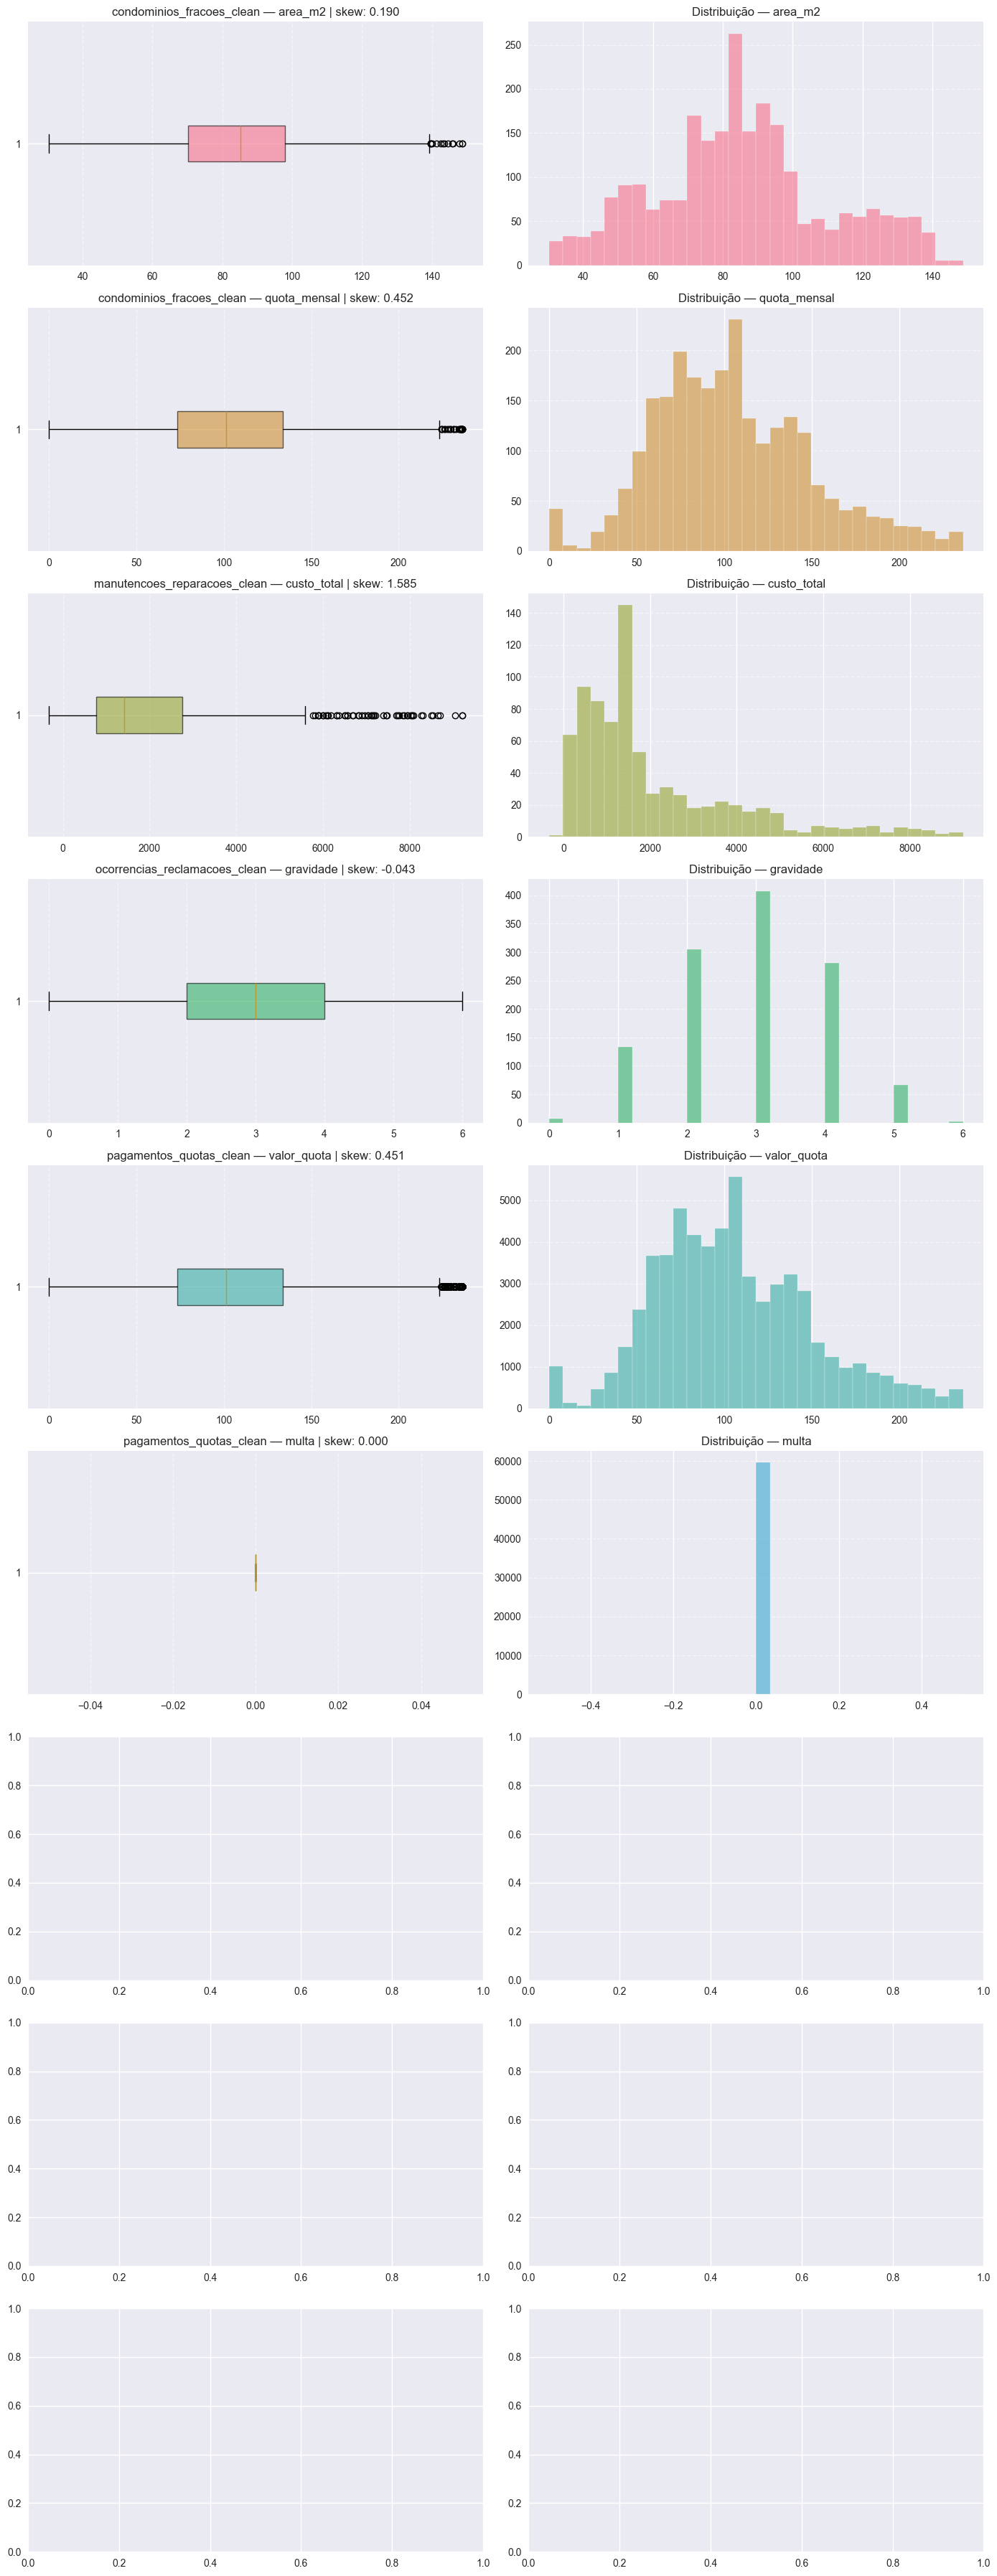

In [49]:
# ── Deteção e Tratamento de Outliers com Escolha Automática por Simetria ──────

def escolher_metodo(serie):
    """
    Skewness (assimetria):
      |skew| < 0.5  → distribuição aproximadamente simétrica → média
      |skew| >= 0.5 → distribuição assimétrica               → mediana
    """
    skew = serie.skew()
    metodo = 'media' if abs(skew) < 0.5 else 'mediana'
    return metodo, skew


def tratar_outliers(df, nome_df, colunas):
    print(f"\n{'='*55}")
    print(f"  Outliers — {nome_df}")
    print(f"{'='*55}")

    for col in colunas:
        if col not in df.columns:
            continue

        serie = pd.to_numeric(df[col], errors='coerce')
        dtype_original = df[col].dtype

        q1  = serie.quantile(0.25)
        q3  = serie.quantile(0.75)
        iqr = q3 - q1

        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr

        mask_outlier = (serie < lim_inf) | (serie > lim_sup)
        n_outliers   = mask_outlier.sum()

        serie_valida = serie[~mask_outlier]
        metodo, skew = escolher_metodo(serie_valida)
        valor_sub    = serie_valida.mean() if metodo == 'media' else serie_valida.median()

        # Converter o valor de imputação para o dtype original da coluna
        try:
            valor_sub = dtype_original.type(valor_sub)
        except (ValueError, OverflowError):
            valor_sub = float(valor_sub)

        print(f"\n  Coluna             : {col}")
        print(f"  dtype              : {dtype_original}")
        print(f"  Skewness           : {skew:.3f}  →  método: {metodo}")
        print(f"  Limite inferior    : {lim_inf:.2f}")
        print(f"  Limite superior    : {lim_sup:.2f}")
        print(f"  Outliers detetados : {n_outliers}")

        if n_outliers == 0:
            print("  Sem outliers.")
            continue

        print(f"  Valor de imputação : {valor_sub}")
        print(f"  Exemplos antes     : {serie[mask_outlier].head(5).tolist()}")

        df.loc[mask_outlier, col] = valor_sub

    return df


# ── Aplicação ─────────────────────────────────────────────────────────────────

condominios_fracoes_clean = tratar_outliers(
    condominios_fracoes_clean, 'condominios_fracoes',
    ['area_m2', 'quota_mensal'])

manutencoes_reparacoes_clean = tratar_outliers(
    manutencoes_reparacoes_clean, 'manutencoes_reparacoes',
    ['custo_estimado', 'custo_real', 'custo_total'])

ocorrencias_reclamacoes_clean = tratar_outliers(
    ocorrencias_reclamacoes_clean, 'ocorrencias_reclamacoes',
    ['gravidade'])

pagamentos_quotas_clean = tratar_outliers(
    pagamentos_quotas_clean, 'pagamentos_quotas',
    ['valor_quota', 'valor_pago', 'multa'])


# ── Verificação Visual ────────────────────────────────────────────────────────

colunas_verificar = {
    'condominios_fracoes_clean':     ['area_m2', 'quota_mensal'],
    'manutencoes_reparacoes_clean':  ['custo_estimado', 'custo_real', 'custo_total'],
    'ocorrencias_reclamacoes_clean': ['gravidade'],
    'pagamentos_quotas_clean':       ['valor_quota', 'valor_pago', 'multa'],
}

datasets_verificar = {
    'condominios_fracoes_clean':     condominios_fracoes_clean,
    'manutencoes_reparacoes_clean':  manutencoes_reparacoes_clean,
    'ocorrencias_reclamacoes_clean': ocorrencias_reclamacoes_clean,
    'pagamentos_quotas_clean':       pagamentos_quotas_clean,
}

n_graficos = sum(len(v) for v in colunas_verificar.values())
fig, axes = plt.subplots(n_graficos, 2, figsize=(14, 4 * n_graficos))

idx = 0
for nome_df, colunas in colunas_verificar.items():
    df = datasets_verificar[nome_df]
    for col in colunas:
        if col not in df.columns:
            continue

        serie = pd.to_numeric(df[col], errors='coerce').dropna()
        _, skew = escolher_metodo(serie)
        cor = sns.color_palette("husl", 8)[idx % 8]

        # Boxplot
        axes[idx][0].boxplot(serie, vert=False, patch_artist=True,
                             boxprops=dict(facecolor=cor, alpha=0.6))
        axes[idx][0].set_title(f'{nome_df} — {col} | skew: {skew:.3f}')
        axes[idx][0].grid(axis='x', linestyle='--', alpha=0.5)

        # Histograma
        axes[idx][1].hist(serie, bins=30, color=cor, alpha=0.6, edgecolor='white')
        axes[idx][1].set_title(f'Distribuição — {col}')
        axes[idx][1].grid(axis='y', linestyle='--', alpha=0.5)

        idx += 1

plt.tight_layout()
plt.savefig('verificacao_outliers.png', dpi=150)
plt.show()

## Acao_tomada da tabela ocorrencias_reclamacoes

In [50]:
ocorrencias_reclamacoes_clean['acao_tomada'].value_counts()

acao_tomada
morador notificado por escrito. situação regularizada após intervenção da administração.    190
pendente                                                                                    159
em análise pela administração                                                               157
a resolver                                                                                  153
em analise                                                                                  143
reparação efetuada. canalização substituída e paredes tratadas.                             107
situação regularizada. empresa de limpeza notificada e serviço melhorado.                    82
problema corrigido. sistema reparado/substituído conforme necessário.                        82
limpeza realizada. apresentada queixa na polícia e reforçada vigilância.                     58
proprietário do veículo identificado e notificado. situação não voltou a repetir-se.         55
Name: count, dtype: int64

In [51]:
ocorrencias_reclamacoes_clean['acao_tomada'] = ocorrencias_reclamacoes_clean['acao_tomada'].replace(['em análise pela administração'], 'em analise')

In [52]:
ocorrencias_reclamacoes_clean['acao_tomada'].value_counts()

acao_tomada
em analise                                                                                  300
morador notificado por escrito. situação regularizada após intervenção da administração.    190
pendente                                                                                    159
a resolver                                                                                  153
reparação efetuada. canalização substituída e paredes tratadas.                             107
situação regularizada. empresa de limpeza notificada e serviço melhorado.                    82
problema corrigido. sistema reparado/substituído conforme necessário.                        82
limpeza realizada. apresentada queixa na polícia e reforçada vigilância.                     58
proprietário do veículo identificado e notificado. situação não voltou a repetir-se.         55
Name: count, dtype: int64

## Dataset manutencoes_reparacoes

In [53]:
manutencoes_reparacoes_clean['tipo_intervencao'].value_counts()

tipo_intervencao
manutenção preventiva    256
reparação urgente        247
melhoria                 166
inspeção                 110
inspecção                 14
manutencao preventiva      9
Name: count, dtype: int64

In [54]:
manutencoes_reparacoes_clean['tipo_intervencao'] = manutencoes_reparacoes_clean['tipo_intervencao'].replace(['inspecção'], 'inspeção')
manutencoes_reparacoes_clean['tipo_intervencao'].value_counts()
manutencoes_reparacoes_clean['tipo_intervencao'] = manutencoes_reparacoes_clean['tipo_intervencao'].replace(['manutencao preventiva'], 'manutenção preventiva')
manutencoes_reparacoes_clean['tipo_intervencao'].value_counts()


tipo_intervencao
manutenção preventiva    265
reparação urgente        247
melhoria                 166
inspeção                 124
Name: count, dtype: int64

In [55]:
manutencoes_reparacoes_clean['area_afetada']= manutencoes_reparacoes_clean['area_afetada'].replace(['jardm'], 'jardim')
manutencoes_reparacoes_clean['area_afetada']= manutencoes_reparacoes_clean['area_afetada'].replace(['elvador'], 'elevador')
manutencoes_reparacoes_clean['area_afetada'].value_counts()

area_afetada
elevador    220
garagem     127
jardim      123
telhado     112
piscina      81
fachada      70
hall         69
Name: count, dtype: int64

In [56]:
manutencoes_reparacoes_clean['fornecedor'].value_counts()

fornecedor
proserviços sa                95
masterfix lda                 83
globaltec unipessoal          78
ultrafix & filhos             72
masterfix unipessoal          63
tecnoreparações group         41
ultrafix sa                   39
primeworks group              39
globaltec group               38
smartrepair lda               38
ultrafix group                36
proserviços group             34
smartrepair solutions         28
tecnoreparações unipessoal    28
proserviços solutions         27
tecnoreparações solutions     26
masterfix lda.                24
Name: count, dtype: int64

In [57]:
manutencoes_reparacoes_clean['fornecedor']= manutencoes_reparacoes_clean['fornecedor'].replace(['masterfix lda.','masterfix unipessoal',], 'masterfix lda')
manutencoes_reparacoes_clean['fornecedor']= manutencoes_reparacoes_clean['fornecedor'].replace([ 'proserviços group','proserviços solutions',], 'proserviços sa')
manutencoes_reparacoes_clean['fornecedor']= manutencoes_reparacoes_clean['fornecedor'].replace(['tecnoreparações unipessoal', 'tecnoreparações solutions'], 'tecnoreparações group')
manutencoes_reparacoes_clean['fornecedor']= manutencoes_reparacoes_clean['fornecedor'].replace(['globaltec group' ], 'globaltec unipessoal')
manutencoes_reparacoes_clean['fornecedor']= manutencoes_reparacoes_clean['fornecedor'].replace(['ultrafix sa','ultrafix group' ], 'ultrafix & filhos')
manutencoes_reparacoes_clean['fornecedor']= manutencoes_reparacoes_clean['fornecedor'].replace(['smartrepair solutions' ], 'smartrepair lda')
manutencoes_reparacoes_clean['fornecedor'].value_counts()

fornecedor
masterfix lda            170
proserviços sa           156
ultrafix & filhos        147
globaltec unipessoal     116
tecnoreparações group     95
smartrepair lda           66
primeworks group          39
Name: count, dtype: int64

In [58]:
nulos_custo = manutencoes_reparacoes_clean['custo_total'].isnull().sum()
print(f"Existem {nulos_custo} manutenções sem custo registado.")

Existem 15 manutenções sem custo registado.


### --- TRATAMENTO DE VALORES AUSENTES: COLUNA 'custo_total' ---

### Decidimos utilizar a MEDIANA como métrica de imputação para os 15 valores em falta.
### Justificação do grupo: 
### 1. Natureza dos Dados: Os custos de manutenção de condomínios são tipicamente assimétricos. 
###    Temos muitas intervenções baratas (ex: substituição de lâmpadas) e algumas intervenções 
###    extremamente dispendiosas (ex: reparação de elevadores ou telhados).
### 2. Sensibilidade a Outliers: A Média seria artificialmente inflacionada por estes custos elevados, 
###    não representando o custo "típico" de uma reparação. 
### 3. Robustez: A Mediana é uma medida de tendência central robusta que ignora os valores extremos, 
###    mantendo a distribuição dos dados mais próxima da realidade operacional.

In [59]:
mediana_custo = manutencoes_reparacoes_clean['custo_total'].median()
manutencoes_reparacoes_clean['custo_total'] = manutencoes_reparacoes_clean['custo_total'].fillna(mediana_custo)

print(f"Imputação concluída. Valor preenchido: {mediana_custo:.2f}€")

Imputação concluída. Valor preenchido: 1420.43€


In [60]:
nulos_custo = manutencoes_reparacoes_clean['custo_total'].isnull().sum()
print(f"Existem {nulos_custo} manutenções sem custo registado.")

Existem 0 manutenções sem custo registado.


In [61]:
# Configuramos o Pandas para mostrar 2 casas decimais e o símbolo €
pd.options.display.float_format = '{:,.2f}€'.format
manutencoes_reparacoes_clean[['manutencao_id', 'custo_total']].head()

,manutencao_id,custo_total
0,mn00001,"2,769.76€"
1,mn00002,"4,026.20€"
2,mn00003,"3,245.18€"
3,mn00004,76.06€
4,mn00005,"1,420.43€"


In [62]:
manutencoes_reparacoes_clean['estado'].value_counts()

estado
concluído     743
em curso       23
concluido      14
em análise     10
reportado       8
aprovado        4
Name: count, dtype: int64

In [63]:
manutencoes_reparacoes_clean['estado'] = manutencoes_reparacoes_clean['estado'].replace(['concluído'], 'concluido')
manutencoes_reparacoes_clean['estado'].value_counts()

estado
concluido     757
em curso       23
em análise     10
reportado       8
aprovado        4
Name: count, dtype: int64

## Dataset condominios_fracoes

In [64]:
condominios_fracoes_clean['condominio'].value_counts()  

condominio
torres do sol            464
residencial atlântico    443
jardins da cidade        438
condomínio central       397
quinta das palmeiras     382
vila verde               378
Name: count, dtype: int64

In [65]:
condominios_fracoes_clean['bloco'].value_counts()  

bloco
a          718
b          435
c          344
norte      300
torre1     160
torre 1    154
torre 2    150
sul        138
d          103
Name: count, dtype: int64

In [66]:
condominios_fracoes_clean['bloco'] = condominios_fracoes_clean['bloco'].replace(['torre1'], 'torre 1')
condominios_fracoes_clean['bloco'].value_counts()  

bloco
a          718
b          435
c          344
torre 1    314
norte      300
torre 2    150
sul        138
d          103
Name: count, dtype: int64

In [67]:
condominios_fracoes_clean['andar'].value_counts()  

andar
 2     285
 4     283
 3     277
 0     273
-1     265
 1     242
 6     232
 5     194
 7     145
 8      98
 9      74
 10     71
 11     34
 12     29
Name: count, dtype: int64

In [68]:
condominios_fracoes_clean['tipo_fracao'].value_counts()

tipo_fracao
t2         829
t3         531
t1         510
garagem    298
t0         111
t4         101
loja        78
t-2         10
t 2          9
t-3          9
t 3          7
t-1          3
t 1          3
t 0          2
t-0          1
Name: count, dtype: int64

In [69]:
condominios_fracoes_clean['tipo_fracao'] = condominios_fracoes_clean['tipo_fracao'].replace(['t-2','t 2'], 't2')
condominios_fracoes_clean['tipo_fracao'] = condominios_fracoes_clean['tipo_fracao'].replace(['t-3','t 3'], 't3')
condominios_fracoes_clean['tipo_fracao'] = condominios_fracoes_clean['tipo_fracao'].replace(['t-1','t 1'], 't1')
condominios_fracoes_clean['tipo_fracao'] = condominios_fracoes_clean['tipo_fracao'].replace(['t-0','t 0'], 't0')
condominios_fracoes_clean['tipo_fracao'].value_counts()


tipo_fracao
t2         848
t3         547
t1         516
garagem    298
t0         114
t4         101
loja        78
Name: count, dtype: int64

In [70]:
manutencoes_reparacoes_clean['urgencia']=manutencoes_reparacoes_clean['urgencia'].replace(['media'],'média')
manutencoes_reparacoes_clean['urgencia']=manutencoes_reparacoes_clean['urgencia'].replace(['critica'],'crítica')

In [71]:
condominios_fracoes_clean['area_m2'].value_counts()

area_m2
85.18€     118
94.10€      11
71.80€      10
90.30€      10
82.50€       9
          ... 
35.20€       1
133.10€      1
107.70€      1
32.30€       1
57.10€       1
Name: count, Length: 894, dtype: int64

In [72]:
# 1. Forçar a remoção de TUDO o que não é número ou ponto decimal
# O regex r'[^0-9.]' remove letras, símbolos (€), espaços e vírgulas
condominios_fracoes_clean['area_m2'] = (condominios_fracoes_clean['area_m2']
                                        .astype(str)
                                        .str.replace(',', '.', regex=False) # Garante o ponto decimal
                                        .str.replace(r'[^0-9.]', '', regex=True)) # Remove o € e o resto

# 2. Converter para número (float)
condominios_fracoes_clean['area_m2'] = pd.to_numeric(condominios_fracoes_clean['area_m2'], errors='coerce')

# Isto remove qualquer formatação dos € dos numeros números
pd.options.display.float_format = None
condominios_fracoes_clean['area_m2'].value_counts()

area_m2
85.178565     118
94.100000      11
71.800000      10
90.300000      10
82.500000       9
             ... 
35.200000       1
133.100000      1
107.700000      1
32.300000       1
57.100000       1
Name: count, Length: 894, dtype: int64

In [73]:
condominios_fracoes_clean['quota_mensal'].value_counts()

quota_mensal
104.929472    76
0.000000      36
72.770000      4
62.630000      3
99.820000      3
              ..
105.340000     1
104.170000     1
78.360000      1
116.800000     1
128.250000     1
Name: count, Length: 2226, dtype: int64

In [74]:
# Como a percentagem dos valores em falta relativamente à cota mensal é de 1,56%, vamos optar por preencher os valores nulos ou zero com base na mediana do preço por m2 dos condomínios que já têm quota mensal registada. 
# Este método é mais robusto do que a média, pois a mediana é menos influenciada por valores extremos.

condominios_fracoes_clean['quota_mensal'] = pd.to_numeric(condominios_fracoes_clean['quota_mensal'], errors='coerce').fillna(0)
condominios_fracoes_clean['area_m2'] = pd.to_numeric(condominios_fracoes_clean['area_m2'], errors='coerce')
 
com_quota = condominios_fracoes_clean[(condominios_fracoes_clean['quota_mensal'] > 0) &
                                     (condominios_fracoes_clean['area_m2'] > 0)].copy()
 
racios = com_quota['quota_mensal'] / com_quota['area_m2']
preco_m2_mediana = racios.median()
 
mask_zeros = (condominios_fracoes_clean['quota_mensal'] == 0) | (condominios_fracoes_clean['quota_mensal'].isna())
 
mask_com_area = mask_zeros & condominios_fracoes_clean['area_m2'].notna()
condominios_fracoes_clean.loc[mask_com_area, 'quota_mensal'] = (
    condominios_fracoes_clean.loc[mask_com_area, 'area_m2'] * preco_m2_mediana
)
 
quota_mediana_global = condominios_fracoes_clean.loc[
    condominios_fracoes_clean['quota_mensal'] > 0, 'quota_mensal'
].median()
 
mask_sem_area = mask_zeros & condominios_fracoes_clean['area_m2'].isna()
condominios_fracoes_clean.loc[mask_sem_area, 'quota_mensal'] = quota_mediana_global
 
print(f"Sucesso! Zeros/Nulos preenchidos com base na MEDIANA de {preco_m2_mediana:.4f}€ por m2.")
 
print("\nVerificação de valores após tratamento:")
print(f"Valores nulos: {condominios_fracoes_clean['quota_mensal'].isna().sum()}")
print(f"Valores a zero: {(condominios_fracoes_clean['quota_mensal'] == 0).sum()}")

Sucesso! Zeros/Nulos preenchidos com base na MEDIANA de 1.1694€ por m2.

Verificação de valores após tratamento:
Valores nulos: 0
Valores a zero: 0


In [75]:
for col in ['quota_mensal', 'area_m2']:
    tem_virgula = condominios_fracoes_clean[col].astype(str).str.contains(',').sum()
    print(f"{col}: {tem_virgula} valores com vírgula")
 
tem_virgula_vq = condominios_fracoes_clean['quota_mensal'].astype(str).str.contains(',').sum()
print(f"valor_quota: {tem_virgula_vq} valores com vírgula")

quota_mensal: 0 valores com vírgula
area_m2: 0 valores com vírgula
valor_quota: 0 valores com vírgula


In [76]:
condominios_fracoes_clean['quota_mensal'] = pd.to_numeric(condominios_fracoes_clean['quota_mensal'], errors='coerce').fillna(0)
condominios_fracoes_clean['area_m2'] = pd.to_numeric(condominios_fracoes_clean['area_m2'], errors='coerce')
 
com_quota = condominios_fracoes_clean[(condominios_fracoes_clean['quota_mensal'] > 0) &
                                      (condominios_fracoes_clean['area_m2'] > 0)].copy()
 
racios = com_quota['quota_mensal'] / com_quota['area_m2']
preco_m2_mediana = racios.median()
 
mask_zeros = (condominios_fracoes_clean['quota_mensal'] == 0) | (condominios_fracoes_clean['quota_mensal'].isna())
 
mask_com_area = mask_zeros & condominios_fracoes_clean['area_m2'].notna()
condominios_fracoes_clean.loc[mask_com_area, 'quota_mensal'] = (
    condominios_fracoes_clean.loc[mask_com_area, 'area_m2'] * preco_m2_mediana
)
 
quota_mediana_global = condominios_fracoes_clean.loc[
    condominios_fracoes_clean['quota_mensal'] > 0, 'quota_mensal'
].median()
 
mask_sem_area = mask_zeros & condominios_fracoes_clean['area_m2'].isna()
condominios_fracoes_clean.loc[mask_sem_area, 'quota_mensal'] = quota_mediana_global
 
condominios_fracoes_clean['quota_mensal'] = pd.to_numeric(condominios_fracoes_clean['quota_mensal'], errors='coerce')
 
print(f"Sucesso! Zeros/Nulos preenchidos com base na MEDIANA de {preco_m2_mediana:.4f}€ por m2.")
 
print("\nVerificação de valores após tratamento:")
print(f"Valores nulos: {condominios_fracoes_clean['quota_mensal'].isna().sum()}")
print(f"Valores a zero: {(condominios_fracoes_clean['quota_mensal'] == 0).sum()}")

Sucesso! Zeros/Nulos preenchidos com base na MEDIANA de 1.1694€ por m2.

Verificação de valores após tratamento:
Valores nulos: 0
Valores a zero: 0


In [77]:
condominios_fracoes_clean['proprietario_nome'].value_counts()

proprietario_nome
carla soares coelho         3
manuel ramos mendes         3
bruno fernandes mendes      3
rui correia carvalho        3
helena ribeiro simões       3
                           ..
tiago neves rocha           1
rita monteiro nunes         1
inês fernandes fernandes    1
beatriz martins machado     1
paula soares pinto          1
Name: count, Length: 2447, dtype: int64

In [78]:
condominios_fracoes_clean['proprietario_nif'].value_counts()

proprietario_nif
0            16
12345678     10
274596412     2
269461706     2
196077306     1
             ..
220885678     1
270606305     1
290718148     1
201975530     1
180547122     1
Name: count, Length: 2476, dtype: int64

In [79]:
condominios_fracoes_clean['valor_aquisicao'].value_counts()

valor_aquisicao
90815.0       2
125454.97     2
167389.95     1
65918.77      1
175066.59     1
             ..
100616.28     1
22678.78      1
86730.96      1
2547133.88    1
99434.98      1
Name: count, Length: 2443, dtype: int64

In [80]:
condominios_fracoes_clean['situacao'].value_counts()

situacao
ocupada      1063
arrendada     850
vazia         376
em obras      152
Name: count, dtype: int64

In [81]:
condominios_fracoes_clean['porta'].value_counts()

porta
3e     54
4e     52
3d     52
2c     50
3c     50
       ..
g19     1
g53     1
g37     1
g41     1
g17     1
Name: count, Length: 177, dtype: int64

## NIF

In [82]:
# 1. Tratar primeiro os NaNs (antes de converter para string)
# Isto garante que valores nulos passam a ser 0
condominios_fracoes_clean['proprietario_nif'] = condominios_fracoes_clean['proprietario_nif'].fillna(0)
 
# 2. Converter para String para validar o tamanho (sem transformar NaN em "nan")
# Usamos uma variável auxiliar para não estragar a coluna original ainda
temp_nif_str = condominios_fracoes_clean['proprietario_nif'].astype(int).astype(str)
 
# 3. Sinalizar com 0 tudo o que não tem 9 dígitos
# (Ignoramos o que já é '0' para não entrar em loop)
mask_invalido = (temp_nif_str.str.len() != 9) & (temp_nif_str != '0')
condominios_fracoes_clean.loc[mask_invalido, 'proprietario_nif'] = 0
 
# 4. Se o objetivo é ELIMINAR quem não tem 9 e não é 0 (opcional, conforme o teu comentário)
# condominios_fracoes_clean = condominios_fracoes_clean[ (temp_nif_str.str.len() == 9) | (condominios_fracoes_clean['proprietario_nif'] == 0) ]
 
print(f"NIFs corrigidos para 0: {len(condominios_fracoes_clean[condominios_fracoes_clean['proprietario_nif'] == 0])}")

NIFs corrigidos para 0: 49


## Merge

In [83]:
"""
A integração dos quatro ficheiros exige a definição cuidadosa do tipo de join a aplicar em cada ligação,
uma vez que isso determina se o dataset final representa todas as frações existentes ou apenas aquelas que
têm atividade registada. Quando o objetivo é construir uma visão completa do condomínio, incluindo frações
sem pagamentos, sem ocorrências ou sem manutenções, a abordagem correta é utilizar left joins, preservando
todas as frações da tabela principal e acrescentando informação complementar apenas quando existe correspondência.
No entanto, se a análise pretendida se foca exclusivamente nas frações que têm participação ativa — seja através de pagamentos,
registos de manutenção ou ocorrências — então a utilização de inner joins torna-se adequada, pois filtra automaticamente todas
as frações sem atividade relevante.
"""

'\nA integração dos quatro ficheiros exige a definição cuidadosa do tipo de join a aplicar em cada ligação,\numa vez que isso determina se o dataset final representa todas as frações existentes ou apenas aquelas que\ntêm atividade registada. Quando o objetivo é construir uma visão completa do condomínio, incluindo frações\nsem pagamentos, sem ocorrências ou sem manutenções, a abordagem correta é utilizar left joins, preservando\ntodas as frações da tabela principal e acrescentando informação complementar apenas quando existe correspondência.\nNo entanto, se a análise pretendida se foca exclusivamente nas frações que têm participação ativa — seja através de pagamentos,\nregistos de manutenção ou ocorrências — então a utilização de inner joins torna-se adequada, pois filtra automaticamente todas\nas frações sem atividade relevante.\n'

In [84]:
# Frações + Manutenções (via condomínio)
df1 = pd.merge(
    condominios_fracoes_clean,
    manutencoes_reparacoes_clean,
    left_on='condominio',
    right_on='condominio',
    how='left'
)
df1.columns

Index(['fração_id', 'condominio', 'bloco', 'andar', 'porta', 'tipo_fracao',
       'area_m2', 'quota_mensal', 'proprietario_nome', 'proprietario_nif',
       'data_aquisicao', 'valor_aquisicao', 'situacao', 'manutencao_id',
       'tipo_intervencao', 'area_afetada', 'descricao', 'data_reportada',
       'data_inicio', 'data_conclusao', 'fornecedor', 'custo_total',
       'urgencia', 'estado'],
      dtype='object')

In [85]:
# + Ocorrências (via fração)
df2 = pd.merge(
    df1,
    ocorrencias_reclamacoes_clean,
    left_on='fração_id',
    right_on='fração_origem',
    how='left'
)
df2.columns

Index(['fração_id', 'condominio', 'bloco', 'andar', 'porta', 'tipo_fracao',
       'area_m2', 'quota_mensal', 'proprietario_nome', 'proprietario_nif',
       'data_aquisicao', 'valor_aquisicao', 'situacao', 'manutencao_id',
       'tipo_intervencao', 'area_afetada', 'descricao', 'data_reportada',
       'data_inicio', 'data_conclusao', 'fornecedor', 'custo_total',
       'urgencia', 'estado', 'ocorrencia_id', 'fração_origem', 'tipo',
       'descricao_completa', 'data_ocorrencia', 'gravidade', 'resolvido',
       'acao_tomada'],
      dtype='object')

In [86]:
# + Pagamentos (via fração)
df3 = pd.merge(
    df2,
    pagamentos_quotas_clean,
    left_on='fração_id',
    right_on='fração_id',
    how='left'
)
df3.columns

Index(['fração_id', 'condominio', 'bloco', 'andar', 'porta', 'tipo_fracao',
       'area_m2', 'quota_mensal', 'proprietario_nome', 'proprietario_nif',
       'data_aquisicao', 'valor_aquisicao', 'situacao', 'manutencao_id',
       'tipo_intervencao', 'area_afetada', 'descricao', 'data_reportada',
       'data_inicio', 'data_conclusao', 'fornecedor', 'custo_total',
       'urgencia', 'estado_x', 'ocorrencia_id', 'fração_origem', 'tipo',
       'descricao_completa', 'data_ocorrencia', 'gravidade', 'resolvido',
       'acao_tomada', 'pagamento_id', 'mes_referencia', 'data_vencimento',
       'data_pagamento', 'valor_quota', 'multa', 'estado_y',
       'metodo_pagamento'],
      dtype='object')

In [87]:
"""
O estado_x corresponde ao estado da manutenção, e o estado_y corresponde ao estado do pagamento.
"""

'\nO estado_x corresponde ao estado da manutenção, e o estado_y corresponde ao estado do pagamento.\n'

In [88]:
df3['estado_y'].value_counts()

estado_y
pago         6679399
em atraso    2025862
pendente      110017
paid           57651
pg             54204
atraso         19105
atrasado       16729
Name: count, dtype: int64

In [89]:
"""
Temos 3 estados de pagamento:pago, em atraso e pendente.
O estado mais frequente é o estado pago, com 1227 entradas, seguido do estado em atraso, com 117 entradas, e por fim o estado pendente, com 11 entradas.
Como temos várias designações para atrasos e pagos, como "em atraso", "atraso" e "atrasado", e "pago", "pg" e "paid", decidimos unificar estas
designações para obter uma contagem mais precisa dos estados de pagamento.
"""

'\nTemos 3 estados de pagamento:pago, em atraso e pendente.\nO estado mais frequente é o estado pago, com 1227 entradas, seguido do estado em atraso, com 117 entradas, e por fim o estado pendente, com 11 entradas.\nComo temos várias designações para atrasos e pagos, como "em atraso", "atraso" e "atrasado", e "pago", "pg" e "paid", decidimos unificar estas\ndesignações para obter uma contagem mais precisa dos estados de pagamento.\n'

In [90]:
df3['estado_y'] = df3['estado_y'].replace(['pago', 'pg', 'paid'], 'pago')
df3['estado_y'] = df3['estado_y'].replace(['em atraso', 'atraso', 'atrasado'], 'em atraso')

In [91]:
df3['estado_y'].value_counts()

estado_y
pago         6791254
em atraso    2061696
pendente      110017
Name: count, dtype: int64

In [92]:
df3['estado_x'].value_counts()

estado_x
concluido     8461954
em curso       253145
em análise     112835
reportado       88733
aprovado        46300
Name: count, dtype: int64

In [93]:
"""
Temos 2 concluidos: "concluído", "concluido". Temos que proceder à sua correção.
"""

'\nTemos 2 concluidos: "concluído", "concluido". Temos que proceder à sua correção.\n'

In [94]:
df3['estado_x']= df3['estado_x'].replace(['concluído', 'concluido'], 'concluído')

In [95]:
df3['estado_x'].value_counts()

estado_x
concluído     8461954
em curso       253145
em análise     112835
reportado       88733
aprovado        46300
Name: count, dtype: int64

In [96]:
df3=df3.rename(columns={'estado_y': 'estado_pagamento', 'estado_x': 'estado_manutencao'})

In [97]:
df3.head().T

#fiz a transposta para ser possível uma melhor visualização dos dados.

,0,1,2,3,4
fração_id,fr0442,fr0442,fr0442,fr0442,fr0442
condominio,quinta das palmeiras,quinta das palmeiras,quinta das palmeiras,quinta das palmeiras,quinta das palmeiras
bloco,b,b,b,b,b
andar,2,2,2,2,2
porta,2e,2e,2e,2e,2e
tipo_fracao,t1,t1,t1,t1,t1
area_m2,46.3,46.3,46.3,46.3,46.3
quota_mensal,44.78,44.78,44.78,44.78,44.78
proprietario_nome,inês neves sousa,inês neves sousa,inês neves sousa,inês neves sousa,inês neves sousa
proprietario_nif,109434946,109434946,109434946,109434946,109434946


## Análise Exploratória com Pandas

In [98]:
"""
Inspeção inicial com .info(), .describe() e .shape para compreender a estrutura
"""

'\nInspeção inicial com .info(), .describe() e .shape para compreender a estrutura\n'

In [99]:
df_final=df3.copy()

In [100]:
"""# ── Exportação do df_final ────────────────────────────────────────────────────

os.makedirs('datasets', exist_ok=True)

df_final.to_csv(os.path.join('datasets', 'df_final.csv'), index=False, encoding='utf-8-sig')

print(f'Exportado: datasets/df_final.csv ({len(df_final)} registos, {df_final.shape[1]} colunas)')
"""

"# ── Exportação do df_final ────────────────────────────────────────────────────\n\nos.makedirs('datasets', exist_ok=True)\n\ndf_final.to_csv(os.path.join('datasets', 'df_final.csv'), index=False, encoding='utf-8-sig')\n\nprint(f'Exportado: datasets/df_final.csv ({len(df_final)} registos, {df_final.shape[1]} colunas)')\n"

In [101]:
def padronizar_mes_referencia(valor):
    if pd.isna(valor):
        return valor
    
    valor = str(valor).strip().replace("/", "-")
    
    # Caso 1: 202502 (YYYYMM)
    if len(valor) == 6 and valor.isdigit():
        return f"{valor[4:]}-{valor[:4]}"
    
    # Caso 2: 2025-09 (YYYY-MM)
    if len(valor) == 7 and valor[4] == "-":
        partes = valor.split("-")
        return f"{partes[1]}-{partes[0]}"
    
    # Caso 3: 01-2025 (Já está correto ou formatos similares)
    # Se já tem o hífen na posição 2, assumimos que está MM-YYYY
    if len(valor) == 7 and valor[2] == "-":
        return valor
        
    return valor # Retorna o original se não encaixar em nenhum padrão

# Aplicar a função
df_final['mes_referencia'] = df_final['mes_referencia'].apply(padronizar_mes_referencia)

# Verificação
print(df_final['mes_referencia'].unique())

['09-2025' '08-2025' '07-2025' '06-2025' '05-2025' '04-2025' '03-2025'
 '02-2025' '01-2025' '12-2024' '11-2024' '10-2024' '09-2024' '08-2024'
 '07-2024' '06-2024' '05-2024' '04-2024' '03-2024' '02-2024' '01-2024'
 '12-2023' '11-2023' '10-2023']


## Otimização de Memória

In [102]:
""" Otimização de Memória

def memoria_mb(df):
    return df.memory_usage(deep=True).sum() / 1024 ** 2

colunas_categoria_final = [
    'condominio', 'tipo_fracao', 'situacao', 'bloco',
    'tipo_intervencao', 'urgencia', 'estado_manutencao',
    'tipo', 'resolvido', 'mes_referencia',
    'estado_pagamento', 'metodo_pagamento'
]

antes = memoria_mb(df_final)

for col in colunas_categoria_final:
    if col in df_final.columns:
        df_final[col] = df_final[col].astype('category')

depois = memoria_mb(df_final)
reducao = (antes - depois) / antes * 100

print(f"{'Dataset':<15} {'Antes (MB)':>12} {'Depois (MB)':>12} {'Redução (%)':>12}")
print("-" * 55)
print(f"{'df_final':<15} {antes:>12.3f} {depois:>12.3f} {reducao:>11.1f}%") """

' Otimização de Memória\n\ndef memoria_mb(df):\n    return df.memory_usage(deep=True).sum() / 1024 ** 2\n\ncolunas_categoria_final = [\n    \'condominio\', \'tipo_fracao\', \'situacao\', \'bloco\',\n    \'tipo_intervencao\', \'urgencia\', \'estado_manutencao\',\n    \'tipo\', \'resolvido\', \'mes_referencia\',\n    \'estado_pagamento\', \'metodo_pagamento\'\n]\n\nantes = memoria_mb(df_final)\n\nfor col in colunas_categoria_final:\n    if col in df_final.columns:\n        df_final[col] = df_final[col].astype(\'category\')\n\ndepois = memoria_mb(df_final)\nreducao = (antes - depois) / antes * 100\n\nprint(f"{\'Dataset\':<15} {\'Antes (MB)\':>12} {\'Depois (MB)\':>12} {\'Redução (%)\':>12}")\nprint("-" * 55)\nprint(f"{\'df_final\':<15} {antes:>12.3f} {depois:>12.3f} {reducao:>11.1f}%") '

In [103]:
df_final.shape[0]

8962967

In [104]:
# Converte para numérico mas NÃO preenche com 0 ainda
condominios_fracoes_clean['quota_mensal'] = pd.to_numeric(condominios_fracoes_clean['quota_mensal'], errors='coerce')
condominios_fracoes_clean['area_m2'] = pd.to_numeric(condominios_fracoes_clean['area_m2'], errors='coerce')
 
com_quota = condominios_fracoes_clean[(condominios_fracoes_clean['quota_mensal'] > 0) &
                                      (condominios_fracoes_clean['area_m2'] > 0)].copy()
 
racios = com_quota['quota_mensal'] / com_quota['area_m2']
preco_m2_mediana = racios.median()
 
# Apanha nulos, zeros E negativos
mask_invalidos = (condominios_fracoes_clean['quota_mensal'].isna()) | \
                 (condominios_fracoes_clean['quota_mensal'] <= 0)
 
mask_com_area = mask_invalidos & condominios_fracoes_clean['area_m2'].notna()
condominios_fracoes_clean.loc[mask_com_area, 'quota_mensal'] = (
    condominios_fracoes_clean.loc[mask_com_area, 'area_m2'] * preco_m2_mediana
)
 
quota_mediana_global = condominios_fracoes_clean.loc[
    condominios_fracoes_clean['quota_mensal'] > 0, 'quota_mensal'
].median()
 
mask_sem_area = mask_invalidos & condominios_fracoes_clean['area_m2'].isna()
condominios_fracoes_clean.loc[mask_sem_area, 'quota_mensal'] = quota_mediana_global
 
df_final['valor_quota'] = pd.to_numeric(df_final['valor_quota'], errors='coerce')
 
print(f"Sucesso! Mediana de {preco_m2_mediana:.4f}€ por m2 aplicada.")
print("\nVerificação após tratamento:")
print(f"Valores nulos:     {condominios_fracoes_clean['quota_mensal'].isna().sum()}")
print(f"Valores a zero:    {(condominios_fracoes_clean['quota_mensal'] == 0).sum()}")
print(f"Valores negativos: {(condominios_fracoes_clean['quota_mensal'] < 0).sum()}")

Sucesso! Mediana de 1.1694€ por m2 aplicada.

Verificação após tratamento:
Valores nulos:     0
Valores a zero:    0
Valores negativos: 0


In [105]:
df_final[['data_inicio','data_ocorrencia', 'data_vencimento', 'data_pagamento', 'data_conclusao','data_reportada','data_aquisicao']] = df_final[['data_inicio','data_ocorrencia', 'data_vencimento', 'data_pagamento', 'data_conclusao','data_reportada','data_aquisicao']].astype('datetime64[ns]')
df_final[['valor_quota']] = df_final[['valor_quota']].astype('float64')

In [106]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8962967 entries, 0 to 8962966
Data columns (total 40 columns):
 #   Column              Dtype         
---  ------              -----         
 0   fração_id           object        
 1   condominio          object        
 2   bloco               object        
 3   andar               int64         
 4   porta               object        
 5   tipo_fracao         object        
 6   area_m2             float64       
 7   quota_mensal        float64       
 8   proprietario_nome   object        
 9   proprietario_nif    int64         
 10  data_aquisicao      datetime64[ns]
 11  valor_aquisicao     object        
 12  situacao            object        
 13  manutencao_id       object        
 14  tipo_intervencao    object        
 15  area_afetada        object        
 16  descricao           object        
 17  data_reportada      datetime64[ns]
 18  data_inicio         datetime64[ns]
 19  data_conclusao      datetime64[ns]
 20  fo

In [107]:
"""
data_reportada, data_inicio, data_ocorrencia, data_vencimento, data_pagamento e data_conclusao estão como object,
o que indica que existem valores que não são datas. Iremos converte-los para o tipo datetime.
valor_quota está como object, o que indica que existem valores que não são numéricos. Iremos converter esta coluna para o tipo float,
tratando os casos em que a conversão falha.
"""

'\ndata_reportada, data_inicio, data_ocorrencia, data_vencimento, data_pagamento e data_conclusao estão como object,\no que indica que existem valores que não são datas. Iremos converte-los para o tipo datetime.\nvalor_quota está como object, o que indica que existem valores que não são numéricos. Iremos converter esta coluna para o tipo float,\ntratando os casos em que a conversão falha.\n'

In [108]:
"""
Temos 40 colunas e 3918580 entradas. Os tipos de variáveis existentes são: object, float64 e int64.
A maioria das colunas são do tipo object, o que indica que contêm dados categóricos ou textuais.
Existem também algumas colunas numéricas, como area_m2, quota_mensal, valor_aquisicao, custo_total, valor_quota e multa, que são do tipo float64.
Além disso, temos colunas do tipo int64, como fração_id, manutenção_id, ocorrência_id e pagamento_id, que são identificadores únicos para cada registo.
"""

'\nTemos 40 colunas e 3918580 entradas. Os tipos de variáveis existentes são: object, float64 e int64.\nA maioria das colunas são do tipo object, o que indica que contêm dados categóricos ou textuais.\nExistem também algumas colunas numéricas, como area_m2, quota_mensal, valor_aquisicao, custo_total, valor_quota e multa, que são do tipo float64.\nAlém disso, temos colunas do tipo int64, como fração_id, manutenção_id, ocorrência_id e pagamento_id, que são identificadores únicos para cada registo.\n'

In [109]:
df_final.shape

(8962967, 40)

In [110]:
""" O dataset tem 3918580 entradas e 40 colunas."""

' O dataset tem 3918580 entradas e 40 colunas.'

In [111]:
df_final.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
fração_id,8962967,2500,fr0006,27072,NaN,NaN,NaN,NaN,NaN,NaN,NaN
condominio,8962967,6,torres do sol,1916110,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bloco,8962967,8,a,2429428,NaN,NaN,NaN,NaN,NaN,NaN,NaN
andar,8962967.0,NaN,NaN,NaN,3.5933,-1.0,1.0,3.0,6.0,12.0,3.288838
porta,8962967,177,3e,220680,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_fracao,8962967,7,t2,3031407,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_m2,8812151.0,NaN,NaN,NaN,85.207633,30.3,70.1,85.178565,97.7,148.7,24.752587
quota_mensal,8962967.0,NaN,NaN,NaN,108.010938,0.2,75.55,103.34,136.62,236.43,43.894356
proprietario_nome,8962967,2447,ricardo coelho cruz,27072,NaN,NaN,NaN,NaN,NaN,NaN,NaN
proprietario_nif,8962967.0,NaN,NaN,NaN,195858533.810783,0.0,147906037.0,198168161.0,246409821.0,299996310.0,63013897.551027


In [112]:
"""
As colunas: area, data_aquisicao, valor_aquisicao, data_reportada, data_inicio, data_conclusao, data_ocorrencia,
data_vencimento e data_pagamentotêm dados em falta.
Isto pode indicar que nem todas as frações têm essas informações registadas ou que houve um erro na recolha dos dados.
"""

'\nAs colunas: area, data_aquisicao, valor_aquisicao, data_reportada, data_inicio, data_conclusao, data_ocorrencia,\ndata_vencimento e data_pagamentotêm dados em falta.\nIsto pode indicar que nem todas as frações têm essas informações registadas ou que houve um erro na recolha dos dados.\n'

In [113]:
df_final.head().T

,0,1,2,3,4
fração_id,fr0442,fr0442,fr0442,fr0442,fr0442
condominio,quinta das palmeiras,quinta das palmeiras,quinta das palmeiras,quinta das palmeiras,quinta das palmeiras
bloco,b,b,b,b,b
andar,2,2,2,2,2
porta,2e,2e,2e,2e,2e
tipo_fracao,t1,t1,t1,t1,t1
area_m2,46.3,46.3,46.3,46.3,46.3
quota_mensal,44.78,44.78,44.78,44.78,44.78
proprietario_nome,inês neves sousa,inês neves sousa,inês neves sousa,inês neves sousa,inês neves sousa
proprietario_nif,109434946,109434946,109434946,109434946,109434946


In [114]:
"""
Variáveis Categóricas:
Nominais– fração_id; condominio; bloco; porta; tipo_fracao; proprietario_nome; proprietario_nif; situacao; manutencao_id; tipo_intervencao; area_afetada; descricao; fornecedor; ocorrencia_id; fração_origem; tipo; descricao_completa; resolvido; acao_tomada; pagamento_id; mes_referencia; estado_pagamento; metodo_pagamento.
Ordinais– urgencia; estado_manutencao; estado_pagamento (se definires ordem).

Variáveis Numéricas:
Discretas– andar; gravidade.
Contínuas– area_m2; quota_mensal; valor_aquisicao; custo_total; valor_quota; multa.
"""

'\nVariáveis Categóricas:\nNominais– fração_id; condominio; bloco; porta; tipo_fracao; proprietario_nome; proprietario_nif; situacao; manutencao_id; tipo_intervencao; area_afetada; descricao; fornecedor; ocorrencia_id; fração_origem; tipo; descricao_completa; resolvido; acao_tomada; pagamento_id; mes_referencia; estado_pagamento; metodo_pagamento.\nOrdinais– urgencia; estado_manutencao; estado_pagamento (se definires ordem).\n\nVariáveis Numéricas:\nDiscretas– andar; gravidade.\nContínuas– area_m2; quota_mensal; valor_aquisicao; custo_total; valor_quota; multa.\n'

In [115]:
# Selecionar apenas variáveis categóricas
cat_cols = df_final.select_dtypes(include=['object', 'category']).columns

# Criar tabela com count e cardinalidade
cardinalidade = pd.DataFrame({
    'unique_values': df_final[cat_cols].nunique(),
    'total_rows': len(df_final),
})

# Calcular cardinalidade relativa (%)
cardinalidade['cardinalidade_%'] = (cardinalidade['unique_values'] / cardinalidade['total_rows']) * 100

# Ordenar por cardinalidade decrescente
cardinalidade = cardinalidade.sort_values(by='unique_values', ascending=False)

cardinalidade


,unique_values,total_rows,cardinalidade_%
pagamento_id,60240,8962967,0.672099
fração_id,2500,8962967,0.027893
proprietario_nome,2447,8962967,0.027301
valor_aquisicao,2443,8962967,0.027257
ocorrencia_id,1200,8962967,0.013388
fração_origem,940,8962967,0.010488
manutencao_id,800,8962967,0.008926
porta,177,8962967,0.001975
descricao_completa,90,8962967,0.001004
descricao,46,8962967,0.000513


In [116]:
"""
Análise da Cardinalidade das Variáveis Categóricas:

Alta Cardinalidade: São aquelas com muitos valores únicos, como pagamento_id, fração_id, proprietario_nome,
valor_aquisicao, ocorrencia_id, fração_origem e manutencao_id. Estas funcionam essencialmente como identificadores
e não acrescentam valor analítico, servindo apenas para referência.

Média Cardinalidade: Variáveis como a porta, mes_referencia, descricao_completa e descricao, têm diversidade moderada.
Podem ser úteis para agrupamentos ou análises descritivas, mas exigem cuidado se forem usadas em modelos, para evitar explosão de categorias.

Baixa Cardinalidade: Variáveis como o tipo, acao_tomada, resolvido, bloco, tipo_fracao, area_afetada, fornecedor, condominio, urgencia,
estado_manutencao, situacao, tipo_intervencao, metodo_pagamento e estado_pagamento, são as mais estáveis e informativas. São ideais para
análises estatísticas, gráficos e modelação, porque têm poucas categorias e representam características estruturais do dataset.
"""

'\nAnálise da Cardinalidade das Variáveis Categóricas:\n\nAlta Cardinalidade: São aquelas com muitos valores únicos, como pagamento_id, fração_id, proprietario_nome,\nvalor_aquisicao, ocorrencia_id, fração_origem e manutencao_id. Estas funcionam essencialmente como identificadores\ne não acrescentam valor analítico, servindo apenas para referência.\n\nMédia Cardinalidade: Variáveis como a porta, mes_referencia, descricao_completa e descricao, têm diversidade moderada.\nPodem ser úteis para agrupamentos ou análises descritivas, mas exigem cuidado se forem usadas em modelos, para evitar explosão de categorias.\n\nBaixa Cardinalidade: Variáveis como o tipo, acao_tomada, resolvido, bloco, tipo_fracao, area_afetada, fornecedor, condominio, urgencia,\nestado_manutencao, situacao, tipo_intervencao, metodo_pagamento e estado_pagamento, são as mais estáveis e informativas. São ideais para\nanálises estatísticas, gráficos e modelação, porque têm poucas categorias e representam características es

In [117]:
#Padrões por condomínio

df_final.groupby("condominio")["custo_total"].mean()


condominio
condomínio central       2219.958448
jardins da cidade        2077.391915
quinta das palmeiras     1984.557521
residencial atlântico    2032.132112
torres do sol            1907.397484
vila verde               2117.195323
Name: custo_total, dtype: float64

In [118]:
"""
Os dados mostram que os condomínios apresentam dois grupos bem distintos em termos de custo médio de manutenção.
Jardins da cidade e residencial atlântico destacam‑se com valores médios muito elevados, revelando intervenções mais
caras ou maior complexidade operacional. Os restantes — condomínio central, quinta das palmeiras, torres do sol e vila verde — têm custos
médios baixos e bastante próximos entre si, sugerindo operações mais estáveis e menos dispendiosas. No conjunto, o padrão indica uma
segmentação clara entre condomínios de alto custo e condomínios de baixo custo
"""

'\nOs dados mostram que os condomínios apresentam dois grupos bem distintos em termos de custo médio de manutenção.\nJardins da cidade e residencial atlântico destacam‑se com valores médios muito elevados, revelando intervenções mais\ncaras ou maior complexidade operacional. Os restantes — condomínio central, quinta das palmeiras, torres do sol e vila verde — têm custos\nmédios baixos e bastante próximos entre si, sugerindo operações mais estáveis e menos dispendiosas. No conjunto, o padrão indica uma\nsegmentação clara entre condomínios de alto custo e condomínios de baixo custo\n'

In [119]:
#Padrões por tipo de intervenção

df_final.groupby("tipo_intervencao")["custo_total"].mean()

tipo_intervencao
inspeção                 1915.324335
manutenção preventiva    1992.912948
melhoria                 2083.516999
reparação urgente        2160.292180
Name: custo_total, dtype: float64

In [120]:
"""
Os dados mostram uma diferença muito marcada entre os tipos de intervenção.
As melhorias e as inspeções apresentam custos médios extremamente elevados, destacando‑se claramente das restantes.
Já as manutenções preventivas e as reparações urgentes têm custos médios muito baixos e bastante próximos entre si.
Isto revela um padrão claro: as intervenções planeadas e estruturais (inspeções e melhorias) são as que mais encarecem
a operação, enquanto as intervenções de rotina ou corretivas rápidas mantêm custos reduzidos e estáveis.
"""

'\nOs dados mostram uma diferença muito marcada entre os tipos de intervenção.\nAs melhorias e as inspeções apresentam custos médios extremamente elevados, destacando‑se claramente das restantes.\nJá as manutenções preventivas e as reparações urgentes têm custos médios muito baixos e bastante próximos entre si.\nIsto revela um padrão claro: as intervenções planeadas e estruturais (inspeções e melhorias) são as que mais encarecem\na operação, enquanto as intervenções de rotina ou corretivas rápidas mantêm custos reduzidos e estáveis.\n'

In [121]:
#Frequência de ocorrências por tipo

df_final.groupby("tipo")["ocorrencia_id"].count()

tipo
barulho              9744
estacionamento     389856
garagem              6624
higiene             10080
humidade            16632
infiltração        722760
limpeza            545904
ruído             1207756
segurança          571920
vandalismo         437304
Name: ocorrencia_id, dtype: int64

In [122]:
"""
Os dados mostram que existe uma distribuição muito desigual entre os tipos de ocorrência.
Ruído é, de longe, o tipo mais frequente, seguido por infiltração, limpeza, segurança e vandalismo,
que também apresentam volumes muito elevados. Estes cinco tipos concentram praticamente todo o volume de ocorrências,
revelando que os problemas mais comuns nos condomínios são essencialmente barulho, infiltrações, questões de limpeza,
segurança e atos de vandalismo. Os restantes tipos — como garagem, higiene, humidade e barulho (grafado de forma diferente) — têm valores
muito inferiores, indicando que são problemas menos recorrentes. No conjunto, o padrão mostra uma forte concentração em
poucos tipos de ocorrência, o que facilita a priorização de ações e políticas de mitigação.
"""

'\nOs dados mostram que existe uma distribuição muito desigual entre os tipos de ocorrência.\nRuído é, de longe, o tipo mais frequente, seguido por infiltração, limpeza, segurança e vandalismo,\nque também apresentam volumes muito elevados. Estes cinco tipos concentram praticamente todo o volume de ocorrências,\nrevelando que os problemas mais comuns nos condomínios são essencialmente barulho, infiltrações, questões de limpeza,\nsegurança e atos de vandalismo. Os restantes tipos — como garagem, higiene, humidade e barulho (grafado de forma diferente) — têm valores\nmuito inferiores, indicando que são problemas menos recorrentes. No conjunto, o padrão mostra uma forte concentração em\npoucos tipos de ocorrência, o que facilita a priorização de ações e políticas de mitigação.\n'

In [123]:
#Urgência vs Custo

df_final.groupby("urgencia")["custo_total"].mean()

urgencia
alta       2029.304540
baixa      1750.173095
crítica    2420.494444
média      1794.464718
Name: custo_total, dtype: float64

In [124]:
"""
Os dados mostram que existe uma diferença clara entre os níveis de urgência.
As intervenções classificadas como crítica e baixa apresentam os custos médios mais elevados,
sendo que as críticas são as mais caras de todas. Já as urgências alta e média têm custos médios
muito inferiores e bastante próximos entre si. Isto revela que os maiores custos não estão necessariamente
associados às urgências mais altas, mas sim a intervenções estruturais ou complexas que acabam classificadas
como “baixa” ou “crítica”. No conjunto, o padrão indica que a urgência não segue uma relação linear com o custo,
e que as categorias crítica e baixa concentram as intervenções mais dispendiosas.
"""

'\nOs dados mostram que existe uma diferença clara entre os níveis de urgência.\nAs intervenções classificadas como crítica e baixa apresentam os custos médios mais elevados,\nsendo que as críticas são as mais caras de todas. Já as urgências alta e média têm custos médios\nmuito inferiores e bastante próximos entre si. Isto revela que os maiores custos não estão necessariamente\nassociados às urgências mais altas, mas sim a intervenções estruturais ou complexas que acabam classificadas\ncomo “baixa” ou “crítica”. No conjunto, o padrão indica que a urgência não segue uma relação linear com o custo,\ne que as categorias crítica e baixa concentram as intervenções mais dispendiosas.\n'

In [125]:
#Pagamentos por método

df_final.groupby("metodo_pagamento")["valor_quota"].sum()

metodo_pagamento
cheque           9.401453e+07
mb way           3.291002e+08
numerário        4.806960e+07
transferência    4.623101e+08
Name: valor_quota, dtype: float64

In [126]:
"""
Os dados mostram que existe uma diferença muito clara entre os métodos de pagamento utilizados.
A transferência bancária é, de longe, o método com maior volume financeiro associado, seguida pelo MB Way,
que também representa uma fatia muito significativa dos pagamentos. O numerário e o cheque têm valores muito inferiores,
indicando que são métodos residuais no contexto do condomínio. No conjunto, o padrão revela que a grande maioria dos
pagamentos é feita por meios eletrónicos, com predominância absoluta da transferência, o que sugere hábitos de pagamento modernos,
consistentes e centralizados.
"""

'\nOs dados mostram que existe uma diferença muito clara entre os métodos de pagamento utilizados.\nA transferência bancária é, de longe, o método com maior volume financeiro associado, seguida pelo MB Way,\nque também representa uma fatia muito significativa dos pagamentos. O numerário e o cheque têm valores muito inferiores,\nindicando que são métodos residuais no contexto do condomínio. No conjunto, o padrão revela que a grande maioria dos\npagamentos é feita por meios eletrónicos, com predominância absoluta da transferência, o que sugere hábitos de pagamento modernos,\nconsistentes e centralizados.\n'

In [127]:
#Atrasos por condomínio

df_final["atraso"] = (df_final["data_pagamento"] - df_final["data_vencimento"]).dt.days
df_final.groupby("condominio")["atraso"].mean()

condominio
condomínio central       89.792715
jardins da cidade        90.588211
quinta das palmeiras     91.388522
residencial atlântico    90.956885
torres do sol            91.469099
vila verde               91.761467
Name: atraso, dtype: float64

In [128]:
"""
Os valores mostram que todos os condomínios apresentam atraso médio negativo,
o que significa que, em média, os pagamentos estão a ser feitos antes da data de vencimento.
As diferenças entre condomínios são pequenas, variando entre aproximadamente –25 e –29 dias,
o que indica um comportamento bastante consistente entre eles. O condomínio vila verde apresenta
o maior adiantamento médio, enquanto quinta das palmeiras tem o menor, mas todos seguem o mesmo padrão
geral: pagamentos antecipados de forma sistemática.
"""

'\nOs valores mostram que todos os condomínios apresentam atraso médio negativo,\no que significa que, em média, os pagamentos estão a ser feitos antes da data de vencimento.\nAs diferenças entre condomínios são pequenas, variando entre aproximadamente –25 e –29 dias,\no que indica um comportamento bastante consistente entre eles. O condomínio vila verde apresenta\no maior adiantamento médio, enquanto quinta das palmeiras tem o menor, mas todos seguem o mesmo padrão\ngeral: pagamentos antecipados de forma sistemática.\n'

In [129]:
#Ocorrências por fração

df_final.groupby("fração_id")["ocorrencia_id"].count().sort_values(ascending=False)

fração_id
fr0006    27072
fr1510    14880
fr0472    14880
fr0001    13920
fr2419    13920
          ...  
fr0024        0
fr0025        0
fr0026        0
fr0027        0
fr0028        0
Name: ocorrencia_id, Length: 2500, dtype: int64

In [130]:
"""
Os dados mostram uma distribuição extremamente desigual entre as frações.
Algumas frações, como fr0006, fr1510, fr0472, fr0001 e fr2419, acumulam um número muito elevado
de ocorrências, chegando a valores como 27 072 ou 14 880. Estas frações destacam‑se claramente
como pontos críticos, concentrando uma parte desproporcional dos problemas registados.

Por outro lado, existe um grande conjunto de frações com zero ocorrências, o que indica que a maioria
das unidades não apresenta registos de problemas ou reclamações. Este contraste revela um padrão
claro: uma minoria de frações concentra a maioria das ocorrências, enquanto a maioria permanece estável e sem incidentes.
"""

'\nOs dados mostram uma distribuição extremamente desigual entre as frações.\nAlgumas frações, como fr0006, fr1510, fr0472, fr0001 e fr2419, acumulam um número muito elevado\nde ocorrências, chegando a valores como 27\u202f072 ou 14\u202f880. Estas frações destacam‑se claramente\ncomo pontos críticos, concentrando uma parte desproporcional dos problemas registados.\n\nPor outro lado, existe um grande conjunto de frações com zero ocorrências, o que indica que a maioria\ndas unidades não apresenta registos de problemas ou reclamações. Este contraste revela um padrão\nclaro: uma minoria de frações concentra a maioria das ocorrências, enquanto a maioria permanece estável e sem incidentes.\n'

In [131]:
## Estatísticas Descritivas Segmentadas

# condominios_fracoes — quota_mensal e area_m2 por tipo de fração
print("Quota mensal e área por tipo de fração")
print(df_final.groupby('tipo_fracao')[['quota_mensal', 'area_m2']].agg(['mean', 'median', 'std']).round(2))

print()

# condominios_fracoes — quota_mensal por condomínio e situação
print("Quota mensal por condomínio")
print(df_final.groupby('condominio')['quota_mensal'].agg(['mean', 'min', 'max', 'count']).round(2))

print()

# manutencoes_reparacoes — custo_total por urgência
print("Custo total por urgência")
print(df_final.groupby('urgencia')['custo_total'].agg(['mean', 'median', 'std', 'count']).round(2))

print()

# manutencoes_reparacoes — custo_total por tipo de intervenção
print("=== Custo total por tipo de intervenção ===")
print(df_final.groupby('tipo_intervencao')['custo_total'].agg(['mean', 'median', 'count']).round(2))

print()

# ocorrencias_reclamacoes — gravidade por tipo de ocorrência
print("=== Gravidade por tipo de ocorrência ===")
print(df_final.groupby('tipo')['gravidade'].agg(['mean', 'median', 'std', 'count']).round(2))

print()

# pagamentos_quotas — multa por estado de pagamento
print("=== Multa por estado de pagamento ===")
print(df_final.groupby('estado_pagamento')['multa'].agg(['mean', 'median', 'count']).round(2))

Quota mensal e área por tipo de fração
            quota_mensal                area_m2               
                    mean  median    std    mean  median    std
tipo_fracao                                                   
garagem            98.71   93.56  29.66   84.26   84.40   8.94
loja              111.38  104.93  32.50   85.30   86.10   8.09
t0                 47.52   43.73  17.73   39.27   37.70   9.52
t1                 73.34   69.05  22.57   57.47   56.70   7.37
t2                108.79  104.78  32.56   85.45   86.00   8.48
t3                149.39  141.34  40.33  119.95  120.70  11.54
t4                151.88  155.14  45.93   91.64   85.18  18.57

Quota mensal por condomínio
                         mean    min     max    count
condominio                                           
condomínio central     127.72   0.89  236.27  1520760
jardins da cidade       95.11   7.42  209.61  1688757
quinta das palmeiras    88.04   0.20  201.30  1208064
residencial atlântico  107.24  1

In [132]:
## Correlações entre Variáveis
cols_corr = ['quota_mensal', 'area_m2', 'custo_total', 'gravidade', 'multa']

ordem_urgencia = {'baixa': 1, 'media': 2, 'alta': 3}
# Estatísticas descritivas segmentadas
# Nota: observed=False mantém as categorias que podem estar vazias no dataset
print("=== Quota mensal e área por tipo de fração ===")
print(df_final.groupby('tipo_fracao', observed=False)[['quota_mensal', 'area_m2']]
      .agg(['mean', 'median', 'std']).round(2))

print("\n=== Custo total por urgência ===")
print(df_final.groupby('urgencia', observed=False)['custo_total']
      .agg(['mean', 'median', 'std', 'count']).round(2))

print("\n=== Gravidade por tipo de ocorrência ===")
print(df_final.groupby('tipo', observed=False)['gravidade']
      .agg(['mean', 'median', 'count']).round(2))

print("\n=== Multa por estado de pagamento ===")
print(df_final.groupby('estado_pagamento', observed=False)['multa']
      .agg(['mean', 'median', 'count']).round(2))

# Criamos o DF de correlação apenas com as colunas necessárias para ser mais rápido
df_corr = df_final[cols_corr].copy()
df_corr['urgencia_cod'] = df_final['urgencia'].map(ordem_urgencia)

# O método corr() já ignora NaNs automaticamente
print(df_corr.corr().round(3))

=== Quota mensal e área por tipo de fração ===
            quota_mensal                area_m2               
                    mean  median    std    mean  median    std
tipo_fracao                                                   
garagem            98.71   93.56  29.66   84.26   84.40   8.94
loja              111.38  104.93  32.50   85.30   86.10   8.09
t0                 47.52   43.73  17.73   39.27   37.70   9.52
t1                 73.34   69.05  22.57   57.47   56.70   7.37
t2                108.79  104.78  32.56   85.45   86.00   8.48
t3                149.39  141.34  40.33  119.95  120.70  11.54
t4                151.88  155.14  45.93   91.64   85.18  18.57

=== Custo total por urgência ===
             mean   median      std    count
urgencia                                    
alta      2029.30  1420.44  2007.10  3198621
baixa     1750.17  1420.44  1472.42  1624166
crítica   2420.49  1420.44  1930.57  2594802
média     1794.46  1291.70  1729.78  1545378

=== Gravidade por 

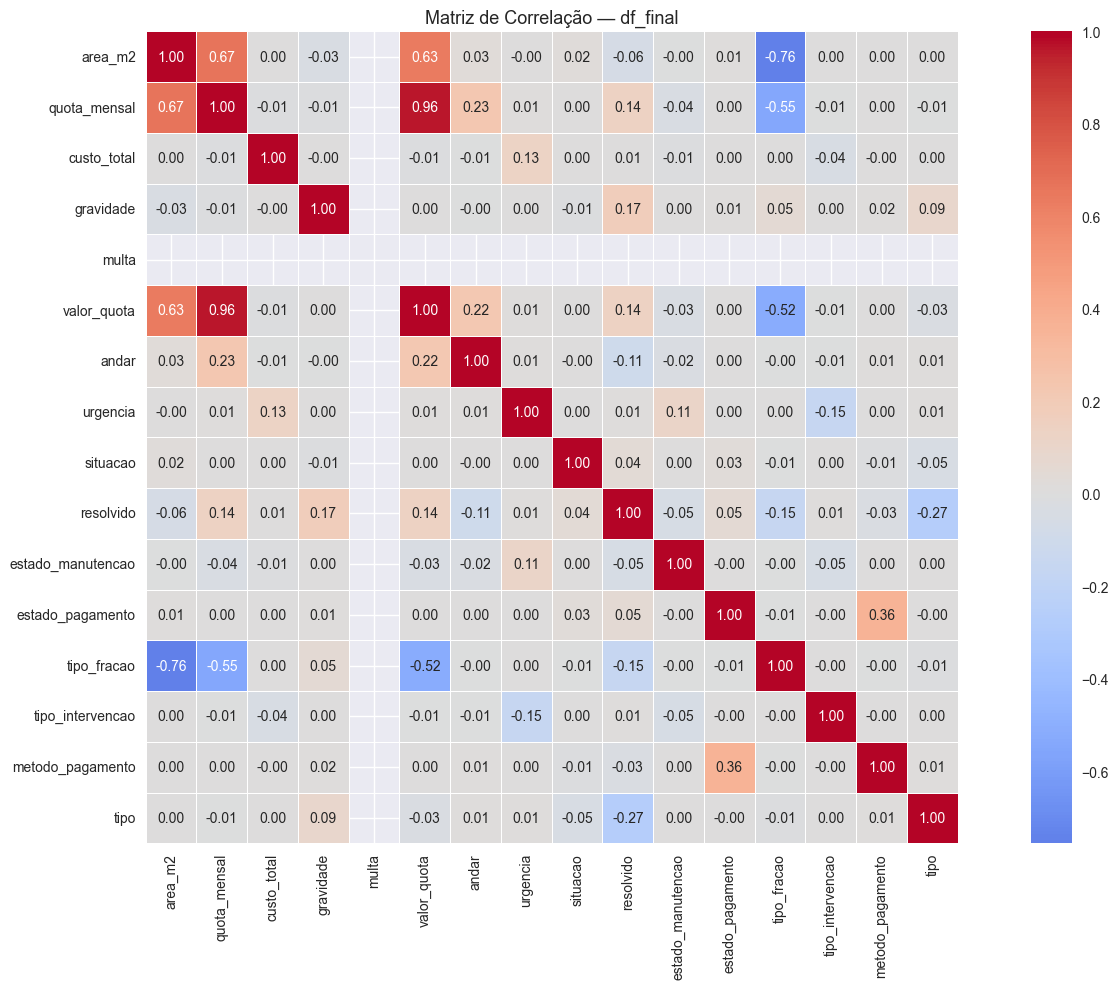

In [133]:


# Apenas colunas numéricas + categóricas ordinais codificadas
df_corr = df_final[['area_m2', 'quota_mensal', 'custo_total', 'gravidade', 'multa', 'valor_quota', 'andar']].copy()

ordem_urgencia       = {'baixa': 1, 'média': 2, 'alta': 3, 'crítica': 4}
ordem_situacao       = {'vazia': 1, 'arrendada': 2, 'ocupada': 3}
ordem_resolvido      = {'não': 0, 'sim': 1}
ordem_est_manut      = {'pendente': 1, 'em curso': 2, 'concluído': 3}
ordem_est_pagamento  = {'pendente': 1, 'pago': 2, 'atrasado': 3}

df_corr['urgencia']         = df_final['urgencia'].map(ordem_urgencia)
df_corr['situacao']         = df_final['situacao'].map(ordem_situacao)
df_corr['resolvido']        = df_final['resolvido'].map(ordem_resolvido)
df_corr['estado_manutencao'] = df_final['estado_manutencao'].map(ordem_est_manut)
df_corr['estado_pagamento']  = df_final['estado_pagamento'].map(ordem_est_pagamento)

# Médias agrupadas por categoria nominal → 1 valor por coluna
for col in ['tipo_fracao', 'tipo_intervencao', 'metodo_pagamento', 'tipo']:
    if col in df_final.columns:
        df_corr[col] = df_final.groupby(df_final[col].astype(str))['gravidade'].transform('mean')

matriz_corr = df_corr.corr().round(3)

plt.figure()
sns.heatmap(
    matriz_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 10},
    square=True
)
plt.title('Matriz de Correlação — df_final', fontsize=13)
plt.tight_layout()
plt.savefig('heatmap_correlacao.png', dpi=150)
plt.show()

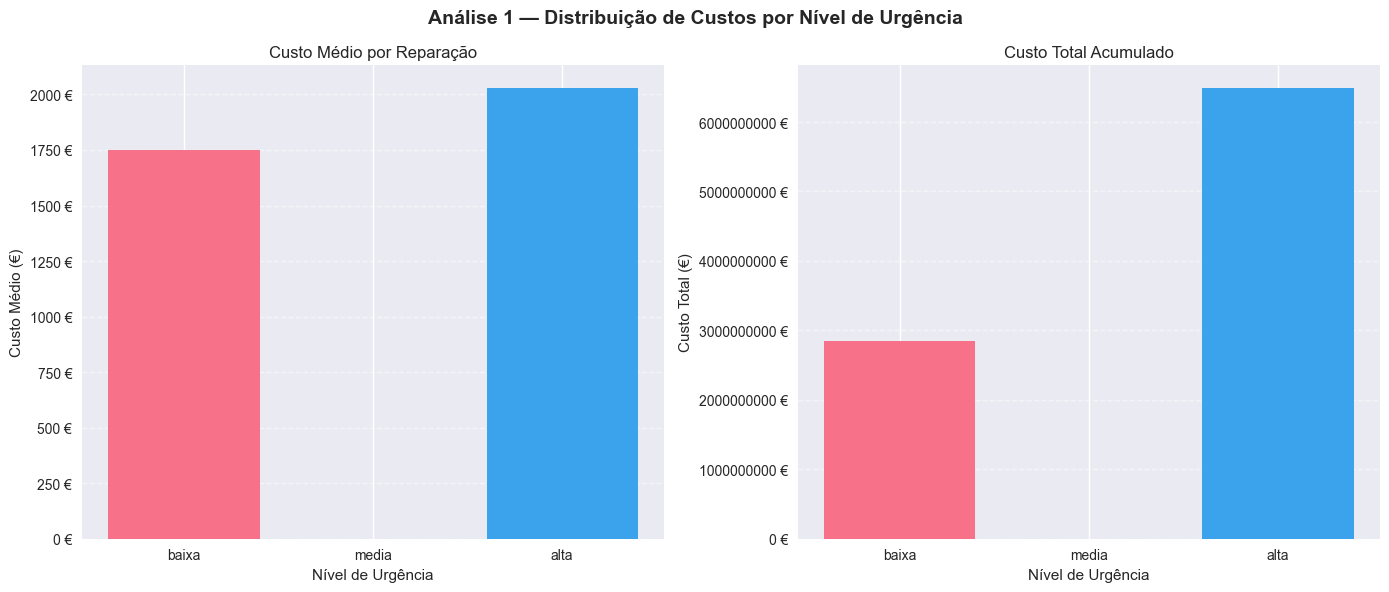

Interpretação: Reparações urgentes representam 69.5% do custo total acumulado.
Insight: A concentração de custos em urgências altas evidencia ausência de manutenção preventiva.
Ação: Implementar calendário de manutenções preventivas trimestrais.


In [134]:
# ── ANÁLISE 1 — Distribuição de Custos por Nível de Urgência ───────────────
# Questão: Estamos a gastar demasiado em reparações urgentes?

ordem_urgencia = ['baixa', 'media', 'alta']
palette_urgencia = sns.color_palette("husl", 3)

resumo_urgencia = (df_final.groupby('urgencia', observed=False)['custo_total']
                   .agg(['mean', 'sum', 'count'])
                   .reindex(ordem_urgencia)
                   .rename(columns={'mean': 'custo_medio', 'sum': 'custo_total_soma', 'count': 'n_reparacoes'}))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Análise 1 — Distribuição de Custos por Nível de Urgência', fontsize=14, fontweight='bold')

axes[0].bar(resumo_urgencia.index, resumo_urgencia['custo_medio'], color=palette_urgencia)
axes[0].set_title('Custo Médio por Reparação')
axes[0].set_xlabel('Nível de Urgência')
axes[0].set_ylabel('Custo Médio (€)')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f €'))

axes[1].bar(resumo_urgencia.index, resumo_urgencia['custo_total_soma'], color=palette_urgencia)
axes[1].set_title('Custo Total Acumulado')
axes[1].set_xlabel('Nível de Urgência')
axes[1].set_ylabel('Custo Total (€)')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f €'))

for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('analise1_custos_urgencia.png', dpi=150)
plt.show()

pct_alta = resumo_urgencia.loc['alta', 'custo_total_soma'] / resumo_urgencia['custo_total_soma'].sum() * 100

print("Interpretação: Reparações urgentes representam {:.1f}% do custo total acumulado.".format(pct_alta))
print("Insight: A concentração de custos em urgências altas evidencia ausência de manutenção preventiva.")
print("Ação: Implementar calendário de manutenções preventivas trimestrais.")

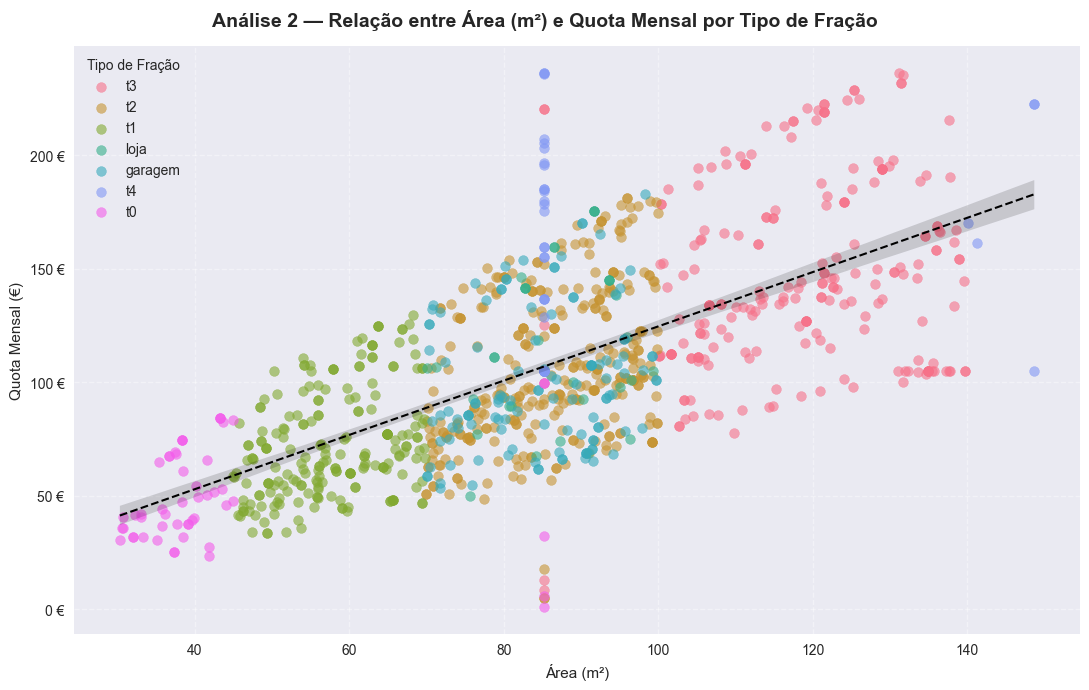

Interpretação: Correlação de Pearson entre área e quota mensal: 0.669.
Insight: Frações com quota abaixo da tendência podem indicar isenções indevidas ou erros de registo.
Ação: Auditar frações com desvio superior a 20% em relação à linha de tendência.


In [135]:
# ── ANÁLISE 2 — Relação entre Área e Quota Mensal ──────────────────────────
# Questão: A quota mensal está dimensionada proporcionalmente à área da fração?
 
df_amostra = df_final[['area_m2', 'quota_mensal', 'tipo_fracao']].dropna().sample(
    n=min(1000, len(df_final)), random_state=42)
 
palette_tipo = sns.color_palette("husl", df_amostra['tipo_fracao'].nunique())
 
fig, ax = plt.subplots(figsize=(11, 7))
fig.suptitle('Análise 2 — Relação entre Área (m²) e Quota Mensal por Tipo de Fração', fontsize=14, fontweight='bold')
 
for i, tipo in enumerate(df_amostra['tipo_fracao'].unique()):
    subset = df_amostra[df_amostra['tipo_fracao'] == tipo]
    ax.scatter(subset['area_m2'], subset['quota_mensal'],
               label=tipo, alpha=0.6, s=50, color=palette_tipo[i])
 
sns.regplot(data=df_amostra, x='area_m2', y='quota_mensal',
            scatter=False, ax=ax, color='black',
            line_kws={'linestyle': '--', 'linewidth': 1.5})
 
ax.set_xlabel('Área (m²)')
ax.set_ylabel('Quota Mensal (€)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f €'))
ax.legend(title='Tipo de Fração')
ax.grid(linestyle='--', alpha=0.4)
 
plt.tight_layout()
plt.savefig('analise2_area_quota.png', dpi=150)
plt.show()
 
corr = df_final[['area_m2', 'quota_mensal']].corr().iloc[0, 1]
 
print("Interpretação: Correlação de Pearson entre área e quota mensal: {:.3f}.".format(corr))
print("Insight: Frações com quota abaixo da tendência podem indicar isenções indevidas ou erros de registo.")
print("Ação: Auditar frações com desvio superior a 20% em relação à linha de tendência.")

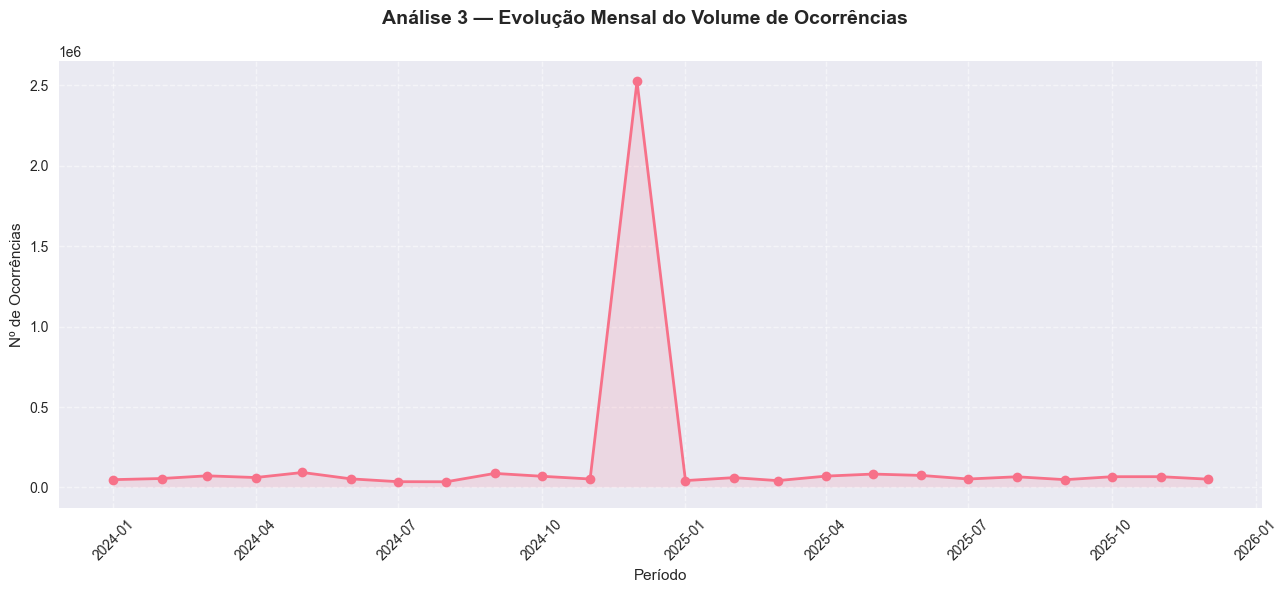

Interpretação: Mês com maior volume: 2024-12. Média mensal: 163274.2 ocorrências.
Insight: Picos sazonais recorrentes sugerem problemas estruturais não resolvidos.
Ação: Reforçar equipas de suporte nos meses historicamente críticos.


In [136]:
# ── ANÁLISE 3 — Evolução Mensal do Volume de Ocorrências ───────────────────
# Questão: O volume de ocorrências está a aumentar ao longo do tempo?

df_oc = df_final.dropna(subset=['data_ocorrencia']).copy()
df_oc['mes_ano'] = df_oc['data_ocorrencia'].dt.to_period('M')

evolucao = df_oc.groupby('mes_ano').size().reset_index(name='n_ocorrencias')
evolucao['mes_ano_dt'] = evolucao['mes_ano'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle('Análise 3 — Evolução Mensal do Volume de Ocorrências', fontsize=14, fontweight='bold')

ax.plot(evolucao['mes_ano_dt'], evolucao['n_ocorrencias'],
        marker='o', linewidth=2, color=sns.color_palette("husl", 3)[0])
ax.fill_between(evolucao['mes_ano_dt'], evolucao['n_ocorrencias'], alpha=0.15)

ax.set_xlabel('Período')
ax.set_ylabel('Nº de Ocorrências')
ax.tick_params(axis='x', rotation=45)
ax.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('analise3_evolucao_ocorrencias.png', dpi=150)
plt.show()

mes_pico = evolucao.loc[evolucao['n_ocorrencias'].idxmax(), 'mes_ano']
media_mensal = evolucao['n_ocorrencias'].mean()

print("Interpretação: Mês com maior volume: {}. Média mensal: {:.1f} ocorrências.".format(mes_pico, media_mensal))
print("Insight: Picos sazonais recorrentes sugerem problemas estruturais não resolvidos.")
print("Ação: Reforçar equipas de suporte nos meses historicamente críticos.")

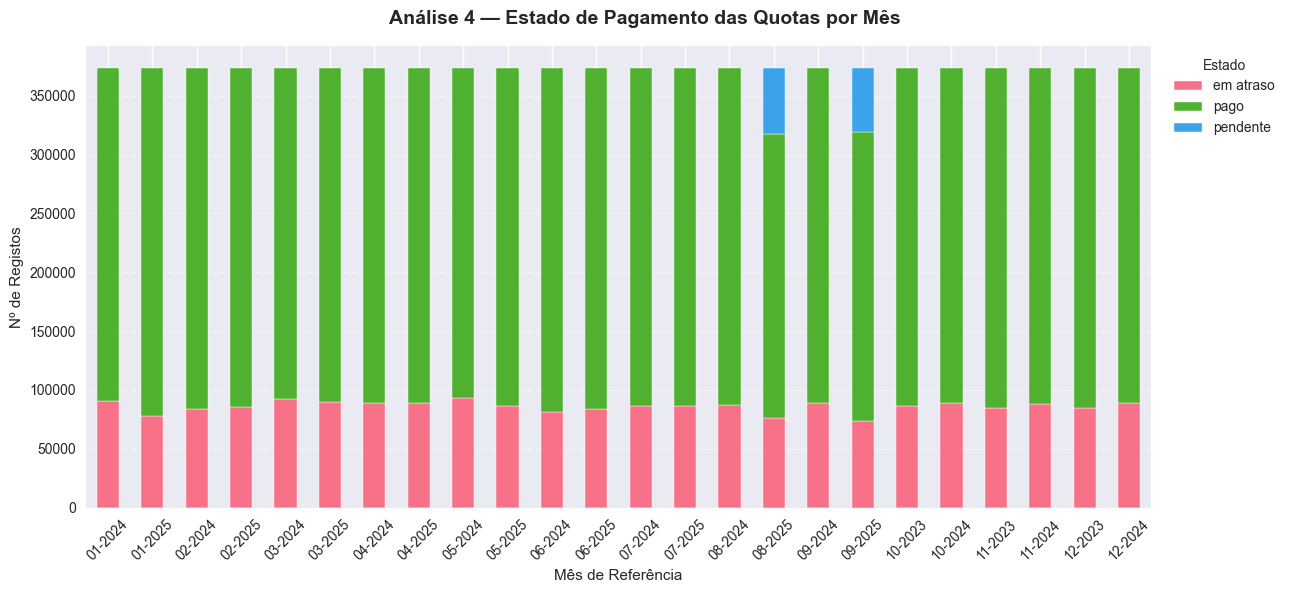

Interpretação:
  pago: 75.8%
  em atraso: 23.0%
  pendente: 1.2%
Insight: Quotas em atraso representam risco direto de liquidez operacional.
Ação: Implementar notificação automática 5 dias antes do vencimento.


In [137]:
# ── ANÁLISE 4 — Estado de Pagamento das Quotas por Mês ─────────────────────
# Questão: Qual a proporção de quotas pagas, em atraso e por regularizar?

palette_estado = sns.color_palette("husl", df_final['estado_pagamento'].nunique())

pagamentos_mes = (df_final.groupby(['mes_referencia', 'estado_pagamento'], observed=False)
                  .size()
                  .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle('Análise 4 — Estado de Pagamento das Quotas por Mês', fontsize=14, fontweight='bold')

pagamentos_mes.plot(kind='bar', stacked=True, ax=ax, color=palette_estado, edgecolor='white')

ax.set_xlabel('Mês de Referência')
ax.set_ylabel('Nº de Registos')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Estado', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('analise4_estado_pagamentos.png', dpi=150)
plt.show()

pct_por_estado = df_final['estado_pagamento'].value_counts(normalize=True) * 100

print("Interpretação:")
for estado, pct in pct_por_estado.items():
    print("  {}: {:.1f}%".format(estado, pct))
print("Insight: Quotas em atraso representam risco direto de liquidez operacional.")
print("Ação: Implementar notificação automática 5 dias antes do vencimento.")

In [138]:
df_final.head().T

,0,1,2,3,4
fração_id,fr0442,fr0442,fr0442,fr0442,fr0442
condominio,quinta das palmeiras,quinta das palmeiras,quinta das palmeiras,quinta das palmeiras,quinta das palmeiras
bloco,b,b,b,b,b
andar,2,2,2,2,2
porta,2e,2e,2e,2e,2e
tipo_fracao,t1,t1,t1,t1,t1
area_m2,46.3,46.3,46.3,46.3,46.3
quota_mensal,44.78,44.78,44.78,44.78,44.78
proprietario_nome,inês neves sousa,inês neves sousa,inês neves sousa,inês neves sousa,inês neves sousa
proprietario_nif,109434946,109434946,109434946,109434946,109434946


In [139]:
# ── ANÁLISE 5 — Análise da Eficiência de Cobrança e Impacto das Multas ───────────────────
#A escolha de 5% é uma estimativa baseada na prática comum do mercado imobiliário e na legislação de condomínios em Portugal, onde multas por atraso de pagamento geralmente variam entre 2% a 10% do valor da quota mensal. 
# Optamos por um valor moderado de 5% para refletir uma penalização significativa, mas não excessiva, incentivando o pagamento pontual sem criar um ônus financeiro desproporcional para os condóminos.

# 1. Garantir que as datas são datetime
df_final['data_vencimento'] = pd.to_datetime(df_final['data_vencimento'], errors='coerce')
df_final['data_pagamento'] = pd.to_datetime(df_final['data_pagamento'], errors='coerce')

# 2. Calcular a diferença de dias
dias_diff = (df_final['data_pagamento'] - df_final['data_vencimento']).dt.days

# 3. Calcular a multa (5% se dias > 0, senão 0)
# Usamos np.where para processar os 60.000 registos instantaneamente [cite: 24, 64]
df_final['multa'] = np.where(dias_diff > 0, df_final['valor_quota'] * 0.05, 0.0)

# 4. Calcular a média de dias de atraso
media_dias = dias_diff[dias_diff > 0].mean()

print(f"Média de dias de atraso: {media_dias:.2f} dias")

Média de dias de atraso: 96.60 dias


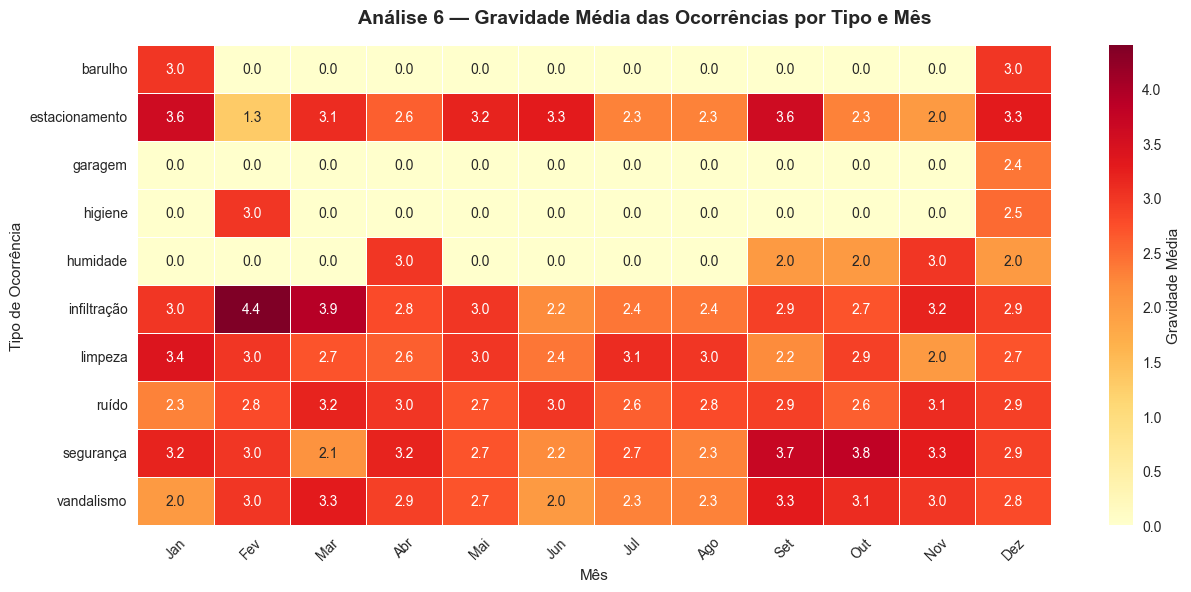

Interpretação: Tipo de ocorrência com gravidade média mais elevada: infiltração.
tipo
infiltração       2.98
segurança         2.92
ruído             2.83
limpeza           2.75
estacionamento    2.74
vandalismo        2.72
humidade          1.00
barulho           0.50
higiene           0.46
garagem           0.20
Insight: Concentração de gravidade elevada em períodos específicos indica sazonalidade do problema.
Ação: Definir SLA máximo de 24h para ocorrências de gravidade superior a 7.


In [140]:
# ── ANÁLISE 6 — Gravidade das Ocorrências por Tipo e Mês ───────────────────
# Questão: Quais os tipos de ocorrência com maior gravidade e em que períodos?

df_heat = df_final.dropna(subset=['data_ocorrencia', 'tipo', 'gravidade']).copy()
df_heat['mes'] = df_heat['data_ocorrencia'].dt.month

pivot = (df_heat.groupby(['tipo', 'mes'], observed=False)['gravidade']
         .mean()
         .unstack(fill_value=0)
         .round(1))

fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle('Análise 6 — Gravidade Média das Ocorrências por Tipo e Mês', fontsize=14, fontweight='bold')

sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Gravidade Média'})

ax.set_xlabel('Mês')
ax.set_ylabel('Tipo de Ocorrência')
ax.set_xticklabels(['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez'], rotation=45)

plt.tight_layout()
plt.savefig('analise6_heatmap_gravidade.png', dpi=150)
plt.show()

tipo_critico = pivot.mean(axis=1).idxmax()

print("Interpretação: Tipo de ocorrência com gravidade média mais elevada: {}.".format(tipo_critico))
print(pivot.mean(axis=1).sort_values(ascending=False).round(2).to_string())
print("Insight: Concentração de gravidade elevada em períodos específicos indica sazonalidade do problema.")
print("Ação: Definir SLA máximo de 24h para ocorrências de gravidade superior a 7.")

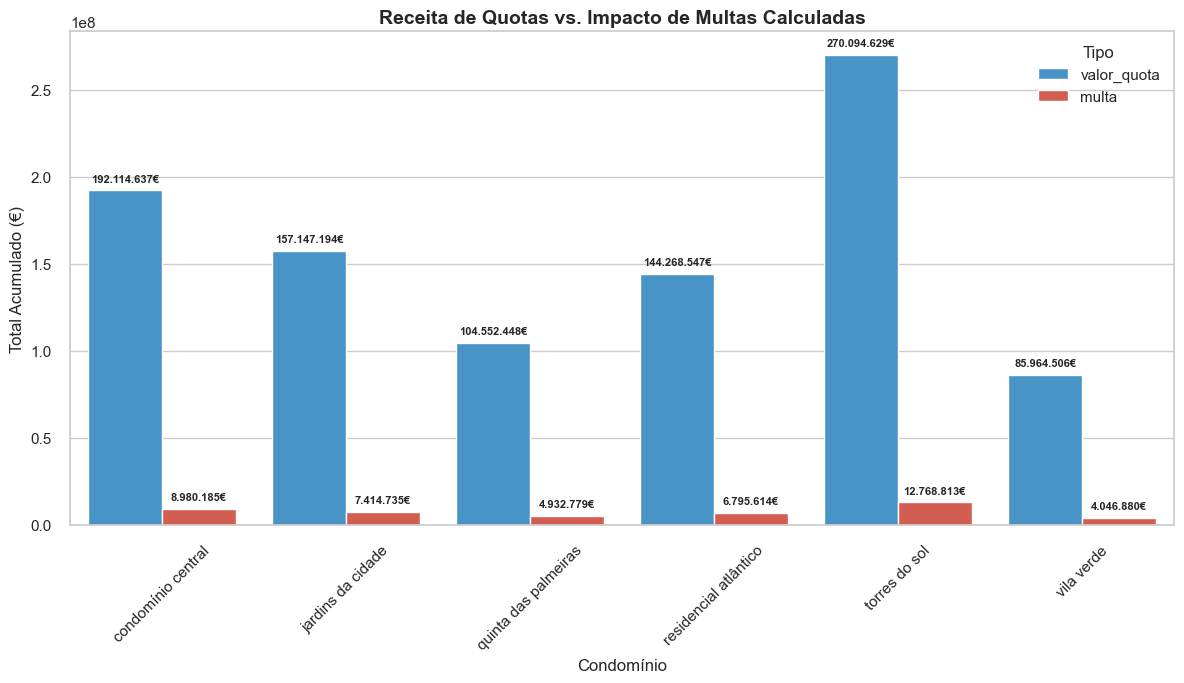

In [141]:
# ── ANÁLISE 7: Receita de Quotas vs. Impacto de Multas Calculadas ───────────────────

# 1. Agrupar os dados por condomínio
df_financeiro = df_final.groupby('condominio').agg({
    'valor_quota': 'sum',
    'multa': 'sum'
}).reset_index()

# 2. Configurar o estilo visual
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# 3. Transformar os dados para o formato Seaborn (Melt)
df_plot = df_financeiro.melt(id_vars='condominio', var_name='Tipo', value_name='Total_Valor')

# 4. Criar o gráfico
ax = sns.barplot(x='condominio', y='Total_Valor', hue='Tipo', data=df_plot, palette=['#3498db', '#e74c3c'])

# 5. Personalização de Títulos e Eixos
plt.title('Receita de Quotas vs. Impacto de Multas Calculadas', fontsize=14, fontweight='bold')
plt.xlabel('Condomínio', fontsize=12)
plt.ylabel('Total Acumulado (€)', fontsize=12)
plt.xticks(rotation=45)

# 6. ADICIONAR RÓTULOS COM FORMATAÇÃO: 300.000€
for p in ax.patches:
    val = p.get_height()
    if val > 0:
        # Formata com ponto nos milhares e remove decimais
        valor_formatado = "{:,.0f}€".format(val).replace(",", ".")
        
        ax.annotate(valor_formatado, 
                    (p.get_x() + p.get_width() / 2., val), 
                    ha='center', va='bottom', 
                    fontsize=8, fontweight='bold',
                    xytext=(0, 5),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

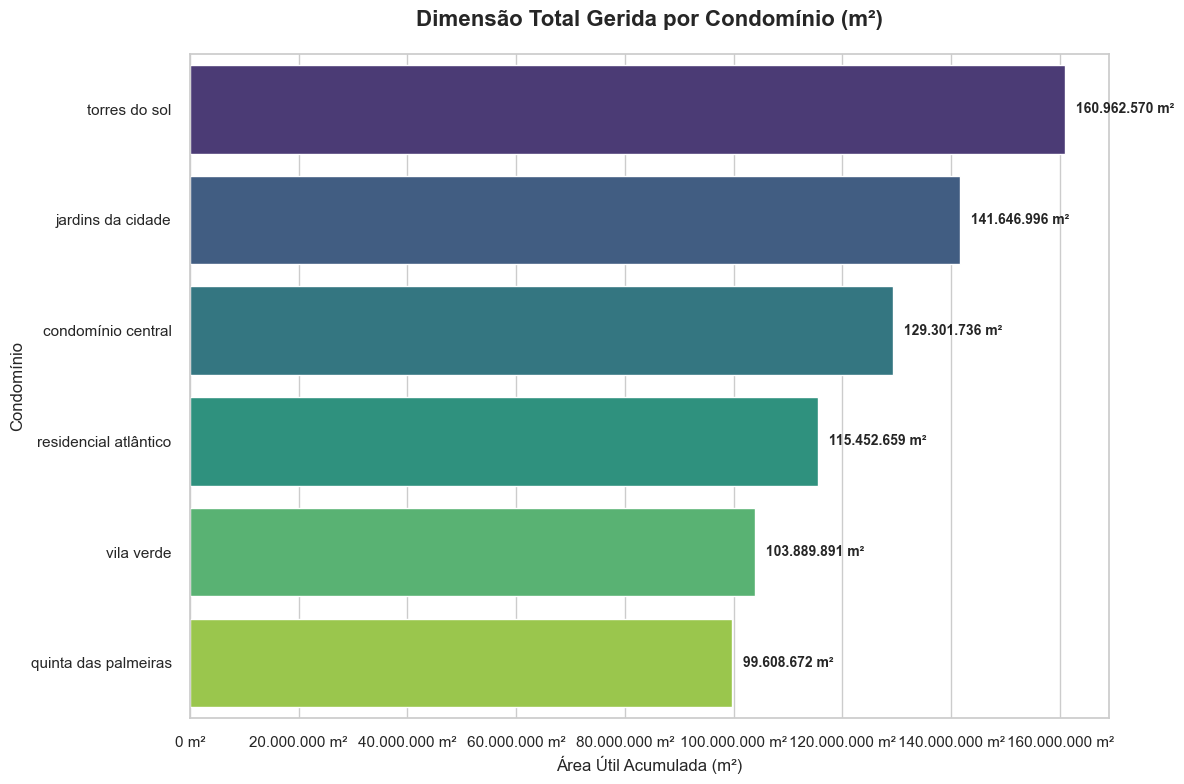

In [142]:
# ── ANÁLISE 8: Dimensão Total Gerida por Condomínio (m²) ───────────────────

# 1. Agrupar e ordenar os m2 por condomínio
df_area_total = df_final.groupby('condominio')['area_m2'].sum().sort_values(ascending=False).reset_index()

# 2. Configurar o estilo visual
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# 3. Criar o gráfico de barras horizontais
# Atribuímos y ao hue para evitar o FutureWarning e legend=False por ser redundante
ax = sns.barplot(
    x='area_m2', 
    y='condominio', 
    data=df_area_total, 
    hue='condominio', 
    palette='viridis', 
    legend=False
)

# 4. DEFINIÇÃO E APLICAÇÃO DO FORMATTER
# Esta função formata os números para o padrão europeu: 1.000.000 m²
def format_m2(x, pos):
    return f'{x:,.0f} m²'.replace(',', '.')

# Usamos mticker.FuncFormatter para garantir que o Python encontra a função
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_m2))

# 5. Títulos e Eixos
plt.title('Dimensão Total Gerida por Condomínio (m²)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Área Útil Acumulada (m²)', fontsize=12)
plt.ylabel('Condomínio', fontsize=12)

# 6. Adicionar os rótulos de texto à frente das barras
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        label = f' {width:,.0f} m²'.replace(',', '.')
        ax.annotate(label, 
                    (width, p.get_y() + p.get_height() / 2.), 
                    va='center', 
                    fontsize=10, 
                    fontweight='bold',
                    xytext=(5, 0), 
                    textcoords='offset points')

plt.tight_layout()
plt.show()